In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

GIORNI_BORSA = 252

# Palette del progetto — Pantone scelti da te
BLU_GENERAL   = "#3B3FB6"   # 2369 C — mondo General
VERDE_ESG     = "#008923"   # mondo ESG (smorzato: 4.6:1 su bianco)
GRIGIO_RUMORE = "#B0AAAB"   # 4282 C — banda e numeri non significativi
NERO_GRAFICO  = "#0C0C11"
FUCSIA        = "#ff2fb0"
BIANCO        = "#F4F4F6"

VERDE_SU   = "#00BB31"      # CAR positivo, solo su fondo nero
ROSSO_GIU  = "#FF3B3B"      # CAR negativo, solo su fondo nero

plt.rcParams["font.family"] = "Arial"

print("pronti —", pd.__version__)

pronti — 3.0.3


In [2]:
TICKER = "META"
BENCH  = "^GSPC"          # S&P 500 = il "mercato"
DATA_NOTIZIA = "2022-02-03"

inizio = pd.Timestamp(DATA_NOTIZIA) - pd.Timedelta(days=280)
fine   = pd.Timestamp(DATA_NOTIZIA) + pd.Timedelta(days=100)

px = yf.download([TICKER, BENCH], start=inizio, end=fine,
                 auto_adjust=True, progress=False)["Close"].dropna()

print(px.shape)
print(px.tail(3))

(264, 2)
Ticker            META        ^GSPC
Date                               
2022-05-11  187.097015  3935.179932
2022-05-12  189.575272  3930.080078
2022-05-13  196.890976  4023.889893


In [3]:
ret = px.pct_change().dropna()
giorni = ret.index

t0 = giorni.searchsorted(pd.Timestamp(DATA_NOTIZIA))
print("giorno 0 =", giorni[t0].date(), "| posizione:", t0)
print("su", len(giorni), "giorni di borsa totali")

giorno 0 = 2022-02-03 | posizione: 193
su 263 giorni di borsa totali


In [4]:
STIMA_FINE = -11     # la stima si ferma 11 giorni prima della notizia
STIMA_LUNG = 120     # e usa 120 giorni di borsa

s0 = t0 + STIMA_FINE - STIMA_LUNG + 1
s1 = t0 + STIMA_FINE

x = ret[BENCH].iloc[s0:s1+1].values      # mercato
y = ret[TICKER].iloc[s0:s1+1].values     # titolo

beta, alfa = np.polyfit(x, y, 1)
resid = y - (alfa + beta * x)
sigma = resid.std(ddof=2)

print(f"periodo di stima: {giorni[s0].date()} → {giorni[s1].date()}")
print(f"beta  = {beta:.2f}   (quanto amplifica il mercato)")
print(f"alfa  = {alfa*100:+.3f}% al giorno")
print(f"sigma = {sigma*100:.2f}%  (il rumore giornaliero normale)")

periodo di stima: 2021-07-30 → 2022-01-19
beta  = 1.31   (quanto amplifica il mercato)
alfa  = -0.111% al giorno
sigma = 1.46%  (il rumore giornaliero normale)


In [5]:
EV = (-1, 3)                    # finestra evento: da 1 giorno prima a 3 dopo
e0, e1 = t0 + EV[0], t0 + EV[1]

ar  = ret[TICKER] - (alfa + beta * ret[BENCH])   # anomalia, ogni giorno
car = ar.iloc[e0:e1+1].sum()                      # sommata sulla finestra

n_giorni = EV[1] - EV[0] + 1
soglia = 1.96 * sigma * np.sqrt(n_giorni)
dentro_rumore = abs(car) < soglia

print(f"finestra [{EV[0]},{EV[1]}] → {giorni[e0].date()} .. {giorni[e1].date()}")
print()
print("giorno   anomalia")
for i in range(e0, e1+1):
    print(f"{giorni[i].date()}   {ar.iloc[i]*100:+6.2f}%")
print()
print(f"CAR    = {car*100:+.2f}%  vs benchmark")
print(f"soglia = ±{soglia*100:.2f}%  (zona rumore)")
print(f"→ {'DENTRO IL RUMORE — non significativo' if dentro_rumore else 'FUORI DAL RUMORE — il mercato ha reagito'}")

finestra [-1,3] → 2022-02-02 .. 2022-02-08

giorno   anomalia
2022-02-02    +0.13%
2022-02-03   -23.09%
2022-02-04    -0.85%
2022-02-07    -4.54%
2022-02-08    -3.09%

CAR    = -31.43%  vs benchmark
soglia = ±6.38%  (zona rumore)
→ FUORI DAL RUMORE — il mercato ha reagito


In [6]:
PX = px.loc[giorni]      # allineo i prezzi ai rendimenti

In [7]:
W = 63                                  # ±3 mesi in giorni di borsa
g0 = max(t0 - W, 0)
g1 = min(t0 + W, len(giorni) - 1)
asse = np.arange(g0, g1 + 1) - t0       # date relative: −63 ... +63

base = t0 - 1                           # ultimo prezzo PRIMA della notizia
tit = PX[TICKER].iloc[g0:g1+1].values / PX[TICKER].iloc[base] * 100
ben = PX[BENCH].iloc[g0:g1+1].values  / PX[BENCH].iloc[base]  * 100

# --- la banda: dove sarebbe Meta se la notizia non contasse niente ---
att = np.full(len(asse), np.nan)
lo  = np.full(len(asse), np.nan)
hi  = np.full(len(asse), np.nan)

j_base = base - g0
att[j_base] = lo[j_base] = hi[j_base] = 100.0

livello = 100.0
for k in range(1, len(asse) - j_base):
    j = j_base + k
    livello *= (1 + alfa + beta * ret[BENCH].iloc[g0 + j])
    att[j] = livello
    banda = 1.96 * sigma * np.sqrt(k)
    lo[j], hi[j] = livello * (1 - banda), livello * (1 + banda)

print("banda al giorno +3:", f"{lo[j_base+4]:.1f} – {hi[j_base+4]:.1f}",
      "| Meta reale:", f"{tit[j_base+4]:.1f}")

banda al giorno +3: 92.1 – 103.2 | Meta reale: 68.2


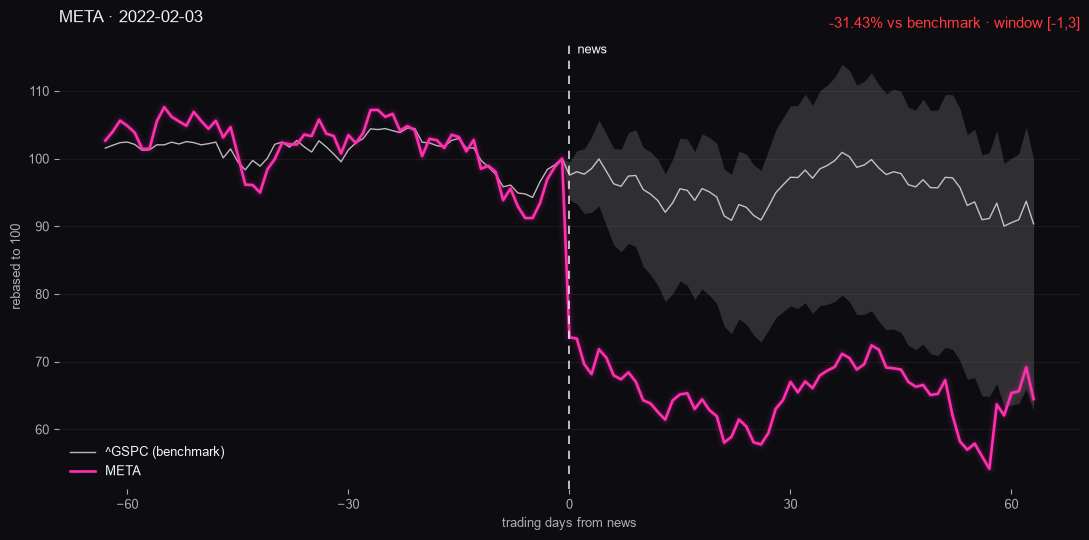

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5), facecolor=NERO_GRAFICO)
ax.set_facecolor(NERO_GRAFICO)

# banda rumore
ax.fill_between(asse, lo, hi, color=GRIGIO_RUMORE, alpha=0.22, linewidth=0, zorder=1)

# benchmark: bianco sottile
ax.plot(asse, ben, color=BIANCO, linewidth=1.0, alpha=0.75, zorder=2,
        label=f"{BENCH} (benchmark)")

# il titolo: fucsia con glow
for lw, al in [(9, 0.04), (6, 0.06), (3.5, 0.12)]:
    ax.plot(asse, tit, color=FUCSIA, linewidth=lw, alpha=al, zorder=3,
            solid_capstyle="round")
ax.plot(asse, tit, color=FUCSIA, linewidth=1.9, zorder=4, label=TICKER)

# LA LINEA VERTICALE DELLA NOTIZIA
ax.axvline(0, color=BIANCO, linestyle=(0, (5, 4)), linewidth=1.2, alpha=0.9, zorder=5)

# pulizia
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(colors=GRIGIO_RUMORE, labelsize=9)
ax.grid(axis="y", color=GRIGIO_RUMORE, alpha=0.10, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xticks([-60, -30, 0, 30, 60])
ax.set_xlabel("trading days from news", color=GRIGIO_RUMORE, fontsize=9)
ax.set_ylabel("rebased to 100", color=GRIGIO_RUMORE, fontsize=9)

ax.text(0, ax.get_ylim()[1], "  news", color=BIANCO, fontsize=9, va="top", ha="left")

leg = ax.legend(loc="lower left", frameon=False, fontsize=9)
for t_ in leg.get_texts():
    t_.set_color(BIANCO)

colore_car = GRIGIO_RUMORE if dentro_rumore else (VERDE_ESG if car > 0 else "#FF3B3B")
ax.set_title(f"{TICKER} · {DATA_NOTIZIA}", color=BIANCO, fontsize=12, loc="left", pad=16)
ax.text(1.0, 1.03, f"{car*100:+.2f}% vs benchmark · window [{EV[0]},{EV[1]}]",
        transform=ax.transAxes, color=colore_car, fontsize=11, ha="right", va="bottom")

plt.tight_layout()
plt.show()

In [9]:
def car(ticker, data_notizia, bench="^GSPC", ev=(-1, 3),
        stima_fine=-11, stima_lung=120, w_graf=63):
    """Rendimento anomalo cumulato attorno a una notizia.
    Restituisce un dizionario. Non disegna, non giudica, non prevede."""

    d0 = pd.Timestamp(data_notizia)
    px = yf.download([ticker, bench],
                     start=d0 - pd.Timedelta(days=300),
                     end=d0 + pd.Timedelta(days=150),
                     auto_adjust=True, progress=False)["Close"].dropna()

    if px.empty or not {ticker, bench} <= set(px.columns):
        return {"ok": False, "motivo": "prezzi non disponibili"}

    ret = px.pct_change().dropna()
    PX, giorni = px.loc[ret.index], ret.index
    t0 = giorni.searchsorted(d0)

    if t0 >= len(giorni):
        return {"ok": False, "motivo": "data fuori dallo storico"}

    s0, s1 = t0 + stima_fine - stima_lung + 1, t0 + stima_fine
    e0, e1 = t0 + ev[0], t0 + ev[1]

    if s0 < 0:
        return {"ok": False, "motivo": "storico insufficiente per la stima"}
    if e1 >= len(giorni):
        return {"ok": False, "motivo": "in consolidamento — finestra non chiusa"}

    # il "normale": stimato SOLO su giorni precedenti la notizia
    x = ret[bench].iloc[s0:s1+1].values
    y = ret[ticker].iloc[s0:s1+1].values
    beta, alfa = np.polyfit(x, y, 1)
    sigma = (y - (alfa + beta * x)).std(ddof=2)

    ar = ret[ticker] - (alfa + beta * ret[bench])
    c = ar.iloc[e0:e1+1].sum()
    soglia = 1.96 * sigma * np.sqrt(ev[1] - ev[0] + 1)

    # serie per la sala
    g0, g1 = max(t0 - w_graf, 0), min(t0 + w_graf, len(giorni) - 1)
    base = t0 - 1
    asse = np.arange(g0, g1 + 1) - t0
    tit = PX[ticker].iloc[g0:g1+1].values / PX[ticker].iloc[base] * 100
    ben = PX[bench].iloc[g0:g1+1].values / PX[bench].iloc[base] * 100

    att = np.full(len(asse), np.nan); lo = att.copy(); hi = att.copy()
    j = base - g0
    att[j] = lo[j] = hi[j] = 100.0
    liv = 100.0
    for k in range(1, len(asse) - j):
        liv *= (1 + alfa + beta * ret[bench].iloc[g0 + j + k])
        att[j + k] = liv
        b = 1.96 * sigma * np.sqrt(k)
        lo[j + k], hi[j + k] = liv * (1 - b), liv * (1 + b)

    return {"ok": True, "ticker": ticker, "bench": bench,
            "data": str(giorni[t0].date()), "ev": ev,
            "car": float(c), "soglia": float(soglia),
            "rumore": bool(abs(c) < soglia),
            "beta": float(beta), "alfa": float(alfa), "sigma": float(sigma),
            "stima": f"{giorni[s0].date()} → {giorni[s1].date()}",
            "asse": asse, "tit": tit, "ben": ben, "lo": lo, "hi": hi}

In [12]:
def grafico(r):
    if not r["ok"]:
        print("niente grafico:", r["motivo"]); return

    fig, ax = plt.subplots(figsize=(11, 5.5), facecolor=NERO_GRAFICO)
    ax.set_facecolor(NERO_GRAFICO)

    ax.fill_between(r["asse"], r["lo"], r["hi"], color=GRIGIO_RUMORE,
                    alpha=0.22, linewidth=0, zorder=1)
    ax.plot(r["asse"], r["ben"], color=BIANCO, linewidth=1.0, alpha=0.75,
            zorder=2, label=f"{r['bench']} (benchmark)")
    for lw, al in [(9, 0.04), (6, 0.06), (3.5, 0.12)]:
        ax.plot(r["asse"], r["tit"], color=FUCSIA, linewidth=lw, alpha=al,
                zorder=3, solid_capstyle="round")
    ax.plot(r["asse"], r["tit"], color=FUCSIA, linewidth=1.9, zorder=4,
            label=r["ticker"])
    ax.axvline(0, color=BIANCO, linestyle=(0, (5, 4)), linewidth=1.2,
               alpha=0.9, zorder=5)

    for s in ax.spines.values(): s.set_visible(False)
    ax.tick_params(colors=GRIGIO_RUMORE, labelsize=9)
    ax.grid(axis="y", color=GRIGIO_RUMORE, alpha=0.10, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_xticks([-60, -30, 0, 30, 60])
    ax.set_xlabel("trading days from news", color=GRIGIO_RUMORE, fontsize=9)
    ax.set_ylabel("rebased to 100", color=GRIGIO_RUMORE, fontsize=9)
    ax.text(0, ax.get_ylim()[1], "  news", color=BIANCO, fontsize=9,
            va="top", ha="left")

    leg = ax.legend(loc="lower left", frameon=False, fontsize=9)
    for t_ in leg.get_texts(): t_.set_color(BIANCO)

    col = GRIGIO_RUMORE if r["rumore"] else (VERDE_SU if r["car"] > 0 else ROSSO_GIU)
    nota = "  · within noise" if r["rumore"] else ""
    ax.set_title(f"{r['ticker']} · {r['data']}", color=BIANCO, fontsize=12,
                 loc="left", pad=16)
    ax.text(1.0, 1.03, f"{r['car']*100:+.2f}% vs benchmark · "
                       f"window [{r['ev'][0]},{r['ev'][1]}]{nota}",
            transform=ax.transAxes, color=col, fontsize=11, ha="right", va="bottom")
    plt.tight_layout(); plt.show()

-31.434654739128824 6.377067347378171 False


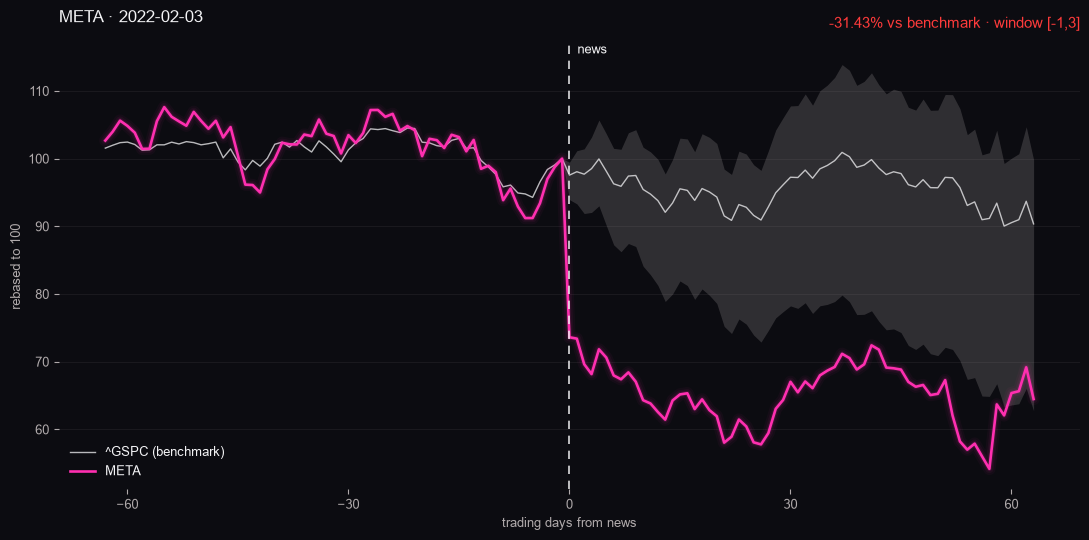

In [13]:
r = car("META", "2022-02-03")
print(r["car"]*100, r["soglia"]*100, r["rumore"])
grafico(r)

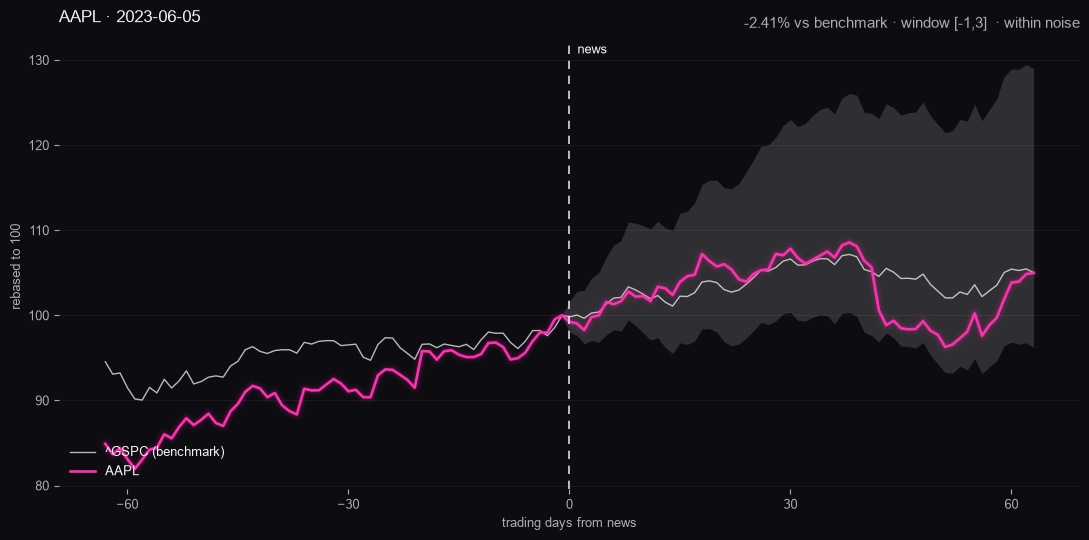

2022-11-25 → 2023-05-18 | beta 1.31 | sigma 0.93


In [14]:
r = car("AAPL", "2023-06-05")
grafico(r)
print(r["stima"], "| beta", round(r["beta"],2), "| sigma", round(r["sigma"]*100,2))

In [15]:
eventi = [
    # ticker,   data,         benchmark, mondo,     titolo originale
    ("META",    "2022-02-03", "^GSPC",   "General", "Meta reports first-ever decline in daily active users"),
    ("AAPL",    "2023-06-05", "^GSPC",   "General", "Apple unveils Vision Pro at WWDC"),
    ("NFLX",    "2022-04-20", "^GSPC",   "General", "Netflix loses subscribers for the first time in a decade"),
    ("NVDA",    "2023-05-25", "^GSPC",   "General", "Nvidia guides revenue far above expectations on AI demand"),
    ("GOOGL",   "2023-02-08", "^GSPC",   "General", "Bard gives a wrong answer in Google's launch demo"),
    ("BA",      "2024-01-08", "^GSPC",   "ESG",     "Alaska Airlines 737 MAX 9 door plug blows out mid-flight"),
    ("XOM",     "2021-05-26", "^GSPC",   "ESG",     "Engine No.1 wins Exxon board seats at shareholder meeting"),
    ("VOW3.DE", "2015-09-21", "^GDAXI",  "ESG",     "EPA notice of violation: Volkswagen emissions defeat devices"),
]

In [16]:
righe = []
for tk, dt, bm, mondo, titolo in eventi:
    r = car(tk, dt, bench=bm)
    if not r["ok"]:
        print(f"✗  {tk:8} {dt}  →  {r['motivo']}")
        continue
    righe.append({"ticker": tk, "data": r["data"], "bench": bm,
                  "mondo": mondo, "titolo": titolo,
                  "car": round(r["car"]*100, 2),
                  "soglia": round(r["soglia"]*100, 2),
                  "rumore": r["rumore"],
                  "beta": round(r["beta"], 2),
                  "sigma": round(r["sigma"]*100, 2)})
    print(f"✓  {tk:8} {r['data']}   CAR {r['car']*100:+7.2f}%   "
          f"soglia ±{r['soglia']*100:.2f}%"
          f"{'   · within noise' if r['rumore'] else ''}")

arch = pd.DataFrame(righe)
arch.to_csv("eventi.csv", index=False)
print(f"\nSALVATO eventi.csv — {len(arch)} eventi, "
      f"{int(arch['rumore'].sum())} dentro il rumore")
arch

✓  META     2022-02-03   CAR  -31.43%   soglia ±6.38%
✓  AAPL     2023-06-05   CAR   -2.41%   soglia ±4.07%   · within noise
✓  NFLX     2022-04-20   CAR  -33.80%   soglia ±12.25%
✓  NVDA     2023-05-25   CAR  +19.78%   soglia ±10.50%
✓  GOOGL    2023-02-08   CAR   -8.24%   soglia ±5.93%
✓  BA       2024-01-08   CAR  -11.70%   soglia ±6.94%
✓  XOM      2021-05-26   CAR   -0.12%   soglia ±9.24%   · within noise
✓  VOW3.DE  2015-09-21   CAR  -27.02%   soglia ±5.01%

SALVATO eventi.csv — 8 eventi, 2 dentro il rumore


,ticker,data,bench,mondo,titolo,car,soglia,rumore,beta,sigma
0,META,2022-02-03,^GSPC,General,Meta reports first-ever decline in daily activ...,-31.43,6.38,False,1.31,1.46
1,AAPL,2023-06-05,^GSPC,General,Apple unveils Vision Pro at WWDC,-2.41,4.07,True,1.31,0.93
2,NFLX,2022-04-20,^GSPC,General,Netflix loses subscribers for the first time i...,-33.80,12.25,False,1.61,2.80
3,NVDA,2023-05-25,^GSPC,General,Nvidia guides revenue far above expectations o...,19.78,10.50,False,2.12,2.40
4,GOOGL,2023-02-08,^GSPC,General,Bard gives a wrong answer in Google's launch demo,-8.24,5.93,False,1.31,1.35
5,BA,2024-01-08,^GSPC,ESG,Alaska Airlines 737 MAX 9 door plug blows out ...,-11.70,6.94,False,0.95,1.58
6,XOM,2021-05-26,^GSPC,ESG,Engine No.1 wins Exxon board seats at sharehol...,-0.12,9.24,True,1.07,2.11
7,VOW3.DE,2015-09-21,^GDAXI,ESG,EPA notice of violation: Volkswagen emissions ...,-27.02,5.01,False,0.98,1.14


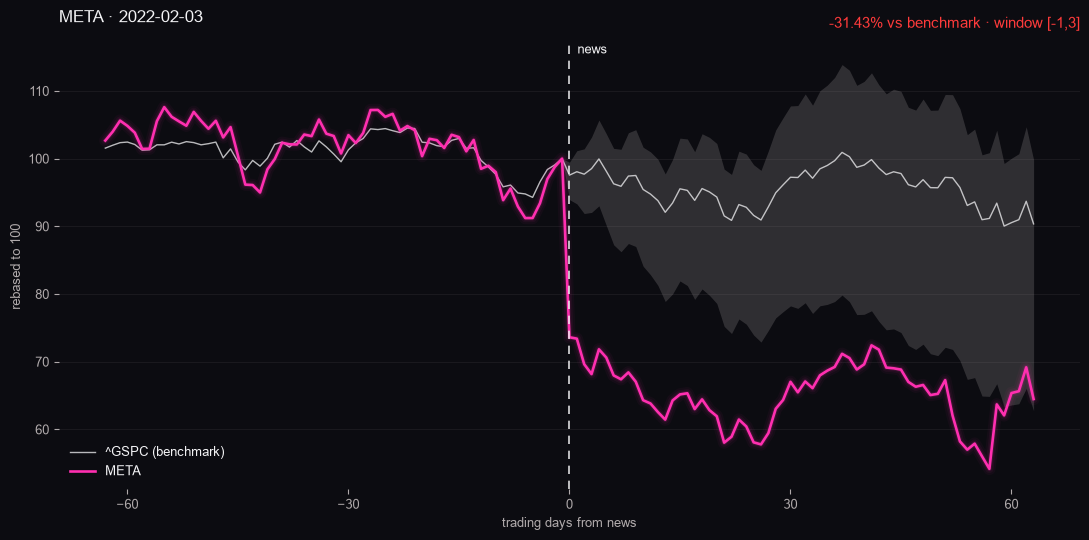

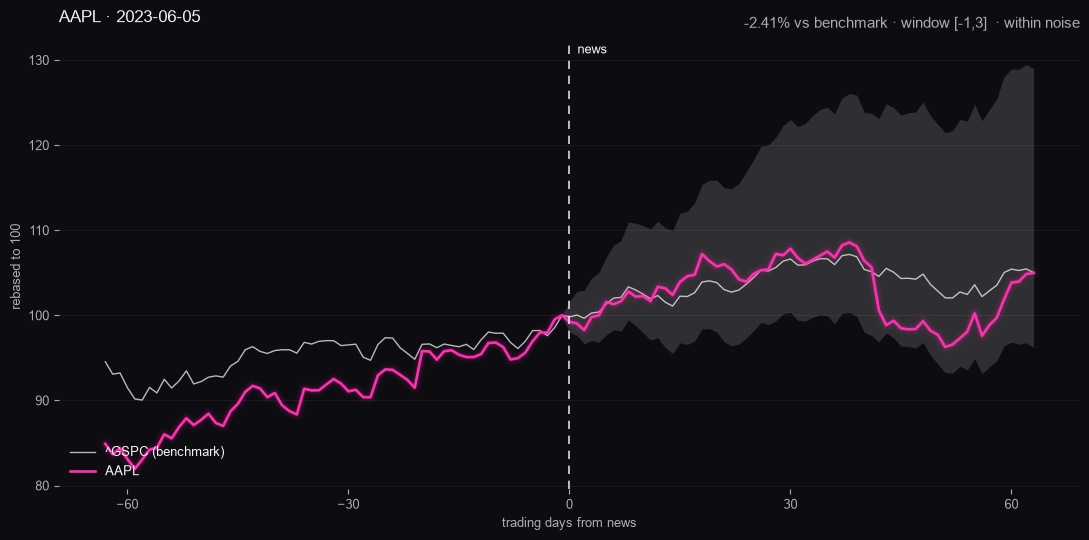

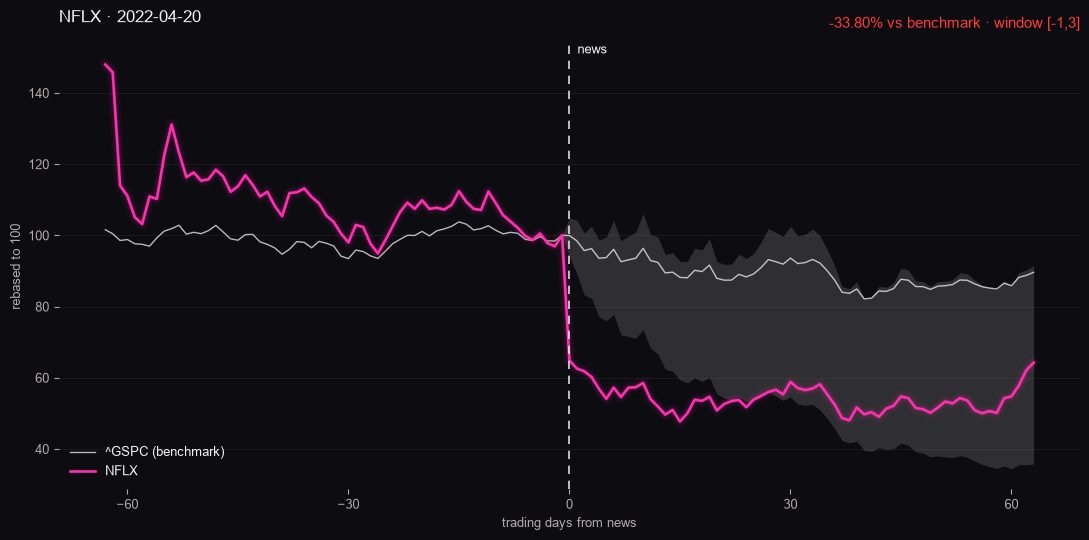

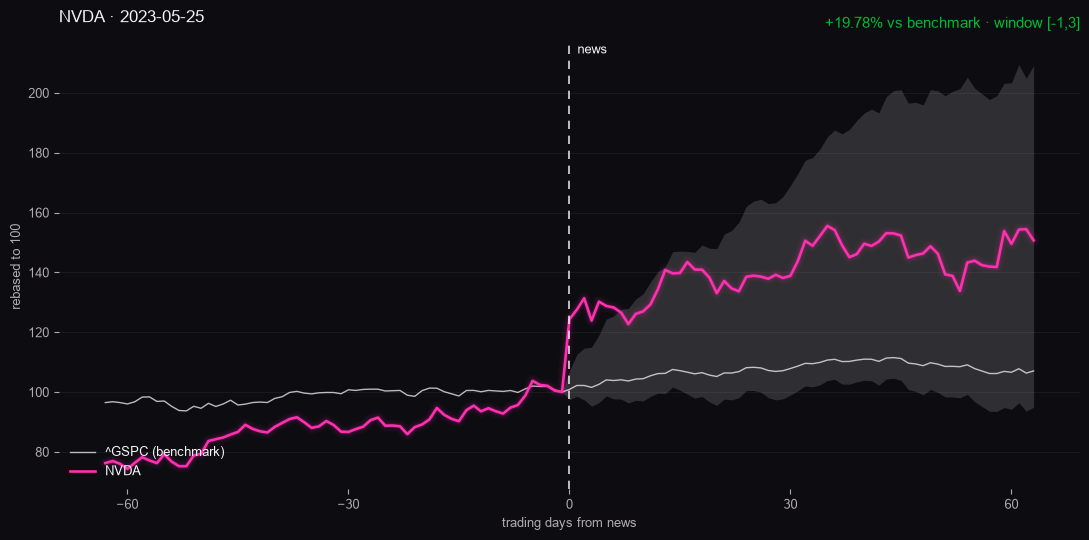

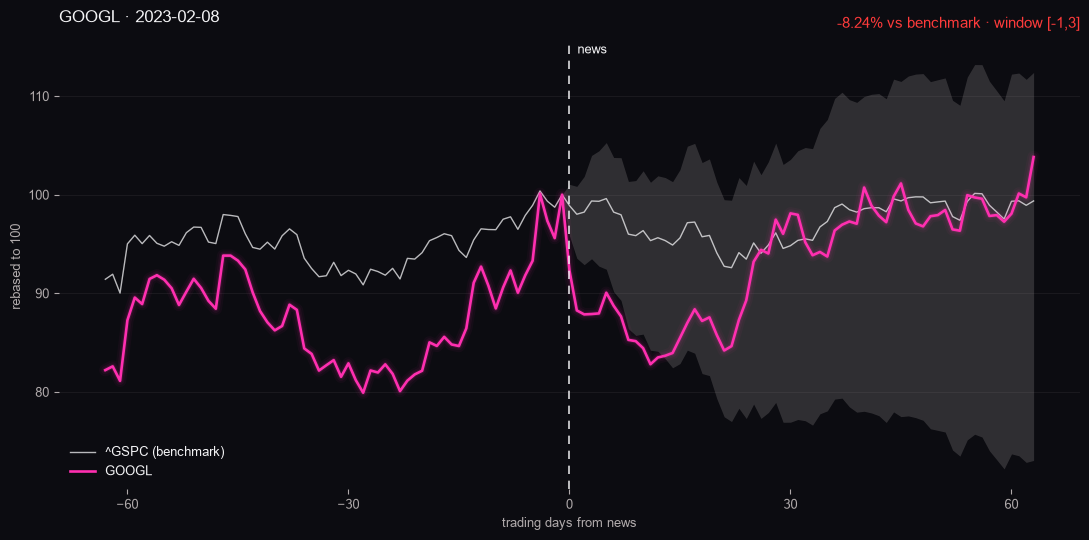

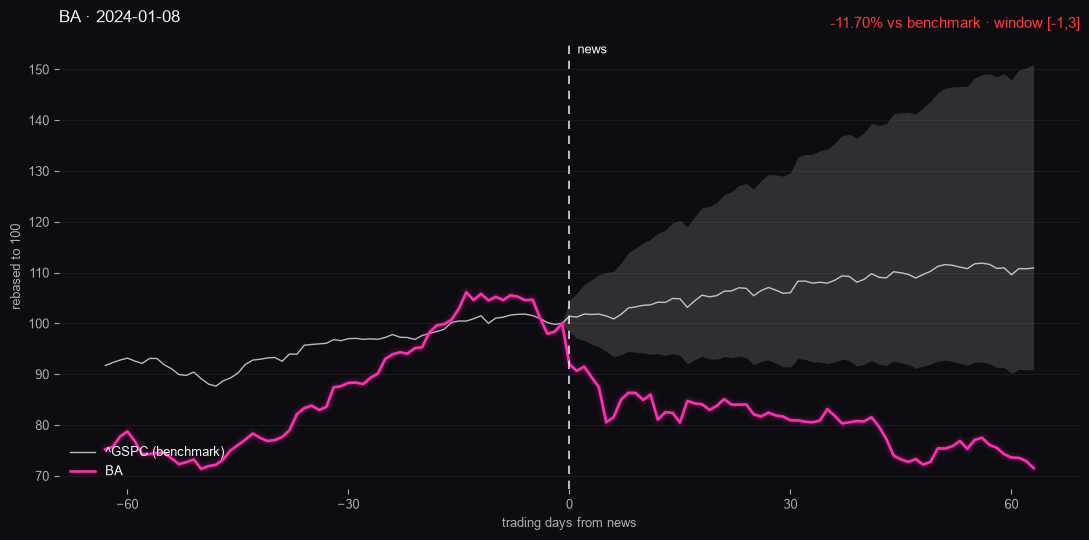

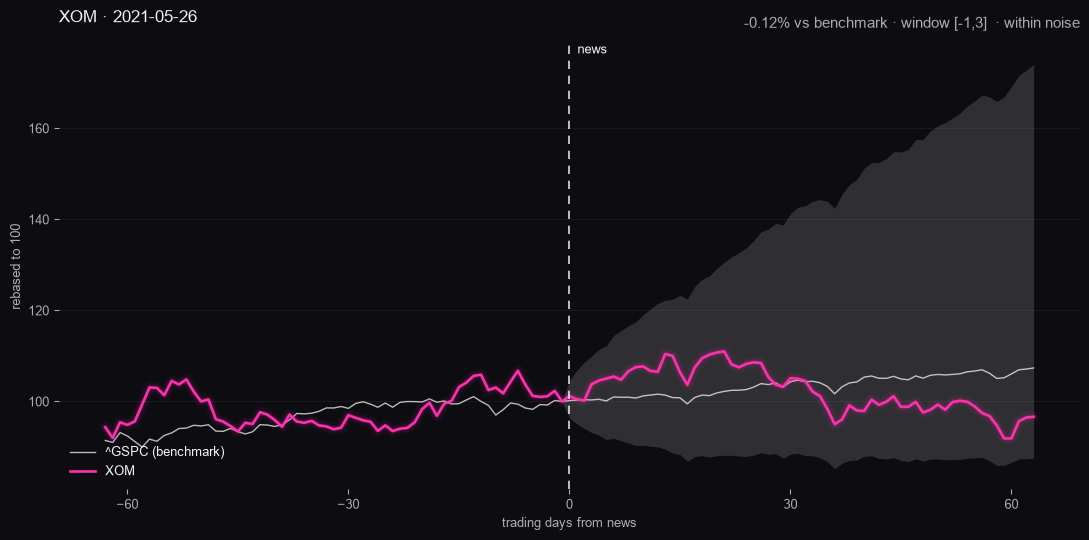

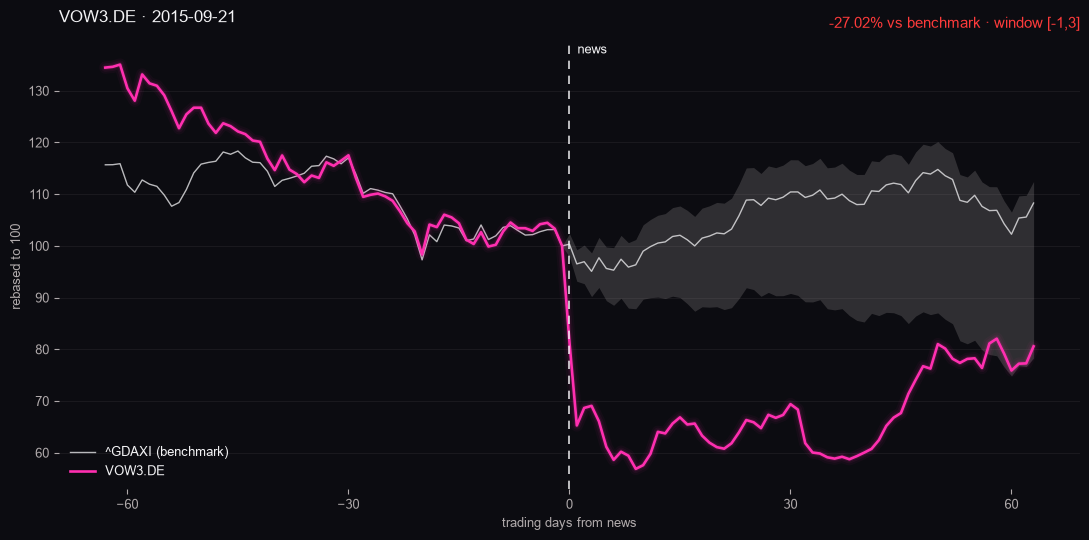

In [17]:
for tk, dt, bm, _, _ in eventi:
    r = car(tk, dt, bench=bm)
    if r["ok"]:
        grafico(r)

In [18]:
h = yf.Ticker("XLC").funds_data.top_holdings
print("tipo:", type(h))
print("colonne:", h.columns.tolist())
print("indice:", h.index.name)
h

tipo: <class 'pandas.DataFrame'>
colonne: ['Name', 'Holding Percent']
indice: Symbol


,Name,Holding Percent
Symbol,,
META,Meta Platforms Inc Class A,0.198818
GOOGL,Alphabet Inc Class A,0.130660
GOOG,Alphabet Inc Class C,0.104127
TTWO,Take-Two Interactive Software Inc,0.052431
NFLX,Netflix Inc,0.048322
CMCSA,Comcast Corp Class A,0.046975
WBD,Warner Bros. Discovery Inc Ordinary Shares - C...,0.046617
EA,Electronic Arts Inc,0.046280
DIS,The Walt Disney Co,0.044767


In [19]:
from datetime import date

ETF_LISTA = ["XLC", "XLK", "XLE", "XLI", "XLF", "QQQ"]

def pesi_oggi(etf):
    """Top holdings di un ETF, come sono OGGI. Con la data di scarico."""
    try:
        h = yf.Ticker(etf).funds_data.top_holdings
    except Exception as e:
        print(f"✗ {etf}: {str(e)[:60]}"); return pd.DataFrame()
    if h is None or len(h) == 0:
        print(f"✗ {etf}: nessuna componente"); return pd.DataFrame()

    d = h.reset_index()
    d.columns = ["ticker", "nome", "peso"]          # ← adatta se la Cella A dice altro
    d["etf"] = etf
    d["data_scarico"] = str(date.today())
    print(f"✓ {etf}: {len(d)} componenti · top-10 = {d['peso'].sum()*100:.1f}% dell'ETF")
    return d[["etf", "ticker", "nome", "peso", "data_scarico"]]

pesi = pd.concat([x for x in (pesi_oggi(e) for e in ETF_LISTA) if len(x)],
                 ignore_index=True)
pesi.to_csv("pesi.csv", index=False)
print(f"\nSALVATO pesi.csv — {len(pesi)} righe")
pesi.head(12)

✓ XLC: 10 componenti · top-10 = 76.0% dell'ETF
✓ XLK: 10 componenti · top-10 = 59.3% dell'ETF
✓ XLE: 10 componenti · top-10 = 71.6% dell'ETF
✓ XLI: 10 componenti · top-10 = 41.4% dell'ETF
✓ XLF: 10 componenti · top-10 = 57.5% dell'ETF
✓ QQQ: 10 componenti · top-10 = 44.9% dell'ETF

SALVATO pesi.csv — 60 righe


,etf,ticker,nome,peso,data_scarico
0,XLC,META,Meta Platforms Inc Class A,0.198818,2026-07-15
1,XLC,GOOGL,Alphabet Inc Class A,0.130660,2026-07-15
2,XLC,GOOG,Alphabet Inc Class C,0.104127,2026-07-15
3,XLC,TTWO,Take-Two Interactive Software Inc,0.052431,2026-07-15
4,XLC,NFLX,Netflix Inc,0.048322,2026-07-15
5,XLC,CMCSA,Comcast Corp Class A,0.046975,2026-07-15
6,XLC,WBD,Warner Bros. Discovery Inc Ordinary Shares - C...,0.046617,2026-07-15
7,XLC,EA,Electronic Arts Inc,0.046280,2026-07-15
8,XLC,DIS,The Walt Disney Co,0.044767,2026-07-15
9,XLC,TMUS,T-Mobile US Inc,0.041461,2026-07-15


In [20]:
def ponte(ticker, pesi=pesi):
    """Quali ETF contengono questo titolo, e con che peso?"""
    m = pesi[pesi["ticker"] == ticker].sort_values("peso", ascending=False)
    return m[["etf", "peso", "data_scarico"]]

print(ponte("META"))
print(ponte("NVDA"))

   etf      peso data_scarico
0  XLC  0.198818   2026-07-15
    etf      peso data_scarico
10  XLK  0.126409   2026-07-15
50  QQQ  0.075827   2026-07-15


In [21]:
def impatto(etf, ticker, data_notizia, bench="^GSPC", ev=(-1, 3), pesi=pesi):
    p = pesi[(pesi["etf"] == etf) & (pesi["ticker"] == ticker)]
    if len(p) == 0:
        return {"ok": False, "motivo": f"{ticker} non è nella top-10 di {etf}"}
    peso, data_peso = float(p["peso"].iloc[0]), p["data_scarico"].iloc[0]

    rt, re_ = car(ticker, data_notizia, bench=bench, ev=ev), car(etf, data_notizia, bench=bench, ev=ev)
    if not rt["ok"]: return {"ok": False, "motivo": f"titolo: {rt['motivo']}"}
    if not re_["ok"]: return {"ok": False, "motivo": f"etf: {re_['motivo']}"}

    atteso = peso * rt["car"]
    return {"ok": True, "etf": etf, "ticker": ticker, "data": rt["data"],
            "peso": peso, "car_titolo": rt["car"], "atteso": atteso,
            "car_etf": re_["car"], "eccesso": re_["car"] - atteso,
            "soglia_etf": re_["soglia"], "etf_rumore": re_["rumore"],
            "eta_peso": (pd.Timestamp(date.today()) - pd.Timestamp(data_notizia)).days}

In [22]:
def riga_fatto(i):
    if not i["ok"]:
        print("—", i["motivo"]); return

    print(f"\n{i['etf']} ← {i['ticker']} · {i['data']}")
    print(f"  {i['ticker']:6} moved      {i['car_titolo']*100:+7.2f}%")
    print(f"  weight in {i['etf']}       {i['peso']*100:6.2f}%")
    print(f"  mechanically expected {i['atteso']*100:+7.2f}%")
    print(f"  {i['etf']:6} actually   {i['car_etf']*100:+7.2f}%   (noise ±{i['soglia_etf']*100:.2f}%)")

    if i["etf_rumore"]:
        v = "ETF within noise — the sector didn't move"
    elif abs(i["eccesso"]) < i["soglia_etf"]:
        v = "company-specific — ETF moved as arithmetic predicts, no spillover"
    else:
        v = f"SPILLOVER — {i['eccesso']*100:+.2f}% beyond the mechanical effect"
    print(f"  → {v}")

    if i["eta_peso"] > 120:
        print(f"  ⚠ weights are TODAY's, event is {i['eta_peso']} days old — indicative only")

riga_fatto(impatto("XLC", "META", "2022-02-03"))
riga_fatto(impatto("XLK", "NVDA", "2023-05-25"))
riga_fatto(impatto("QQQ", "AAPL", "2023-06-05"))


XLC ← META · 2022-02-03
  META   moved       -31.43%
  weight in XLC        19.88%
  mechanically expected   -6.25%
  XLC    actually     -5.30%   (noise ±2.38%)
  → company-specific — ETF moved as arithmetic predicts, no spillover
  ⚠ weights are TODAY's, event is 1623 days old — indicative only

XLK ← NVDA · 2023-05-25
  NVDA   moved       +19.78%
  weight in XLK        12.64%
  mechanically expected   +2.50%
  XLK    actually     +4.18%   (noise ±2.41%)
  → company-specific — ETF moved as arithmetic predicts, no spillover
  ⚠ weights are TODAY's, event is 1147 days old — indicative only

QQQ ← AAPL · 2023-06-05
  AAPL   moved        -2.41%
  weight in QQQ         6.66%
  mechanically expected   -0.16%
  QQQ    actually     -2.27%   (noise ±2.12%)
  → company-specific — ETF moved as arithmetic predicts, no spillover
  ⚠ weights are TODAY's, event is 1136 days old — indicative only


In [23]:
n = yf.Ticker("META").news
print("quante:", len(n))
print("chiavi:", list(n[0].keys()))
print("chiavi content:", list(n[0]["content"].keys()))
n[0]["content"]

quante: 10
chiavi: ['id', 'content']
chiavi content: ['id', 'contentType', 'title', 'description', 'summary', 'pubDate', 'displayTime', 'isHosted', 'bypassModal', 'previewUrl', 'thumbnail', 'provider', 'canonicalUrl', 'clickThroughUrl', 'metadata', 'finance', 'storyline']


{'id': 'ebcb157d-215a-48a6-a046-93376fabd5c6',
 'contentType': 'VIDEO',
 'title': 'Chinese AI model developer DeepSeek preps for IPO: What to know',
 'description': '<p>Chinese large language model (LLM) developer DeepSeek is reportedly preparing for an IPO later this year or in 2027. Yahoo Finance Technology Editor Dan Howley outlines what we know so far.</p>',
 'summary': 'Chinese large language model (LLM) developer DeepSeek is reportedly preparing for an IPO later this year or in 2027. Yahoo Finance Technology Editor Dan Howley outlines what we know so far.',
 'pubDate': '2026-07-14T20:57:29Z',
 'displayTime': '',
 'isHosted': True,
 'bypassModal': False,
 'previewUrl': None,
 'thumbnail': {'originalUrl': 'https://s.yimg.com/uu/api/res/1.2/MSDfU9DFHJfDZGMb602zOg--~B/aD0yODEyO3c9NTAwMDthcHBpZD15dGFjaHlvbg--/https://d29szjachogqwa.cloudfront.net/images/user-uploaded/9b6bb352-90ad-4a2f-b411-d86c77bb83dd_f857b076ecaec34436e43fcf588d2d2aa58a3d798bd95eb3b20117e48c5f9833.jpg',
  'original

In [24]:
def giorno_zero(pub_utc):
    """Primo giorno in cui il mercato USA può reagire alla notizia."""
    t = pd.Timestamp(pub_utc).tz_convert("America/New_York")
    if t.hour >= 16:                      # uscita dopo la chiusura
        t = t + pd.Timedelta(days=1)
    return t.normalize().tz_localize(None)

def notizie(ticker, max_n=8):
    try:
        raw = yf.Ticker(ticker).news
    except Exception as e:
        print(f"✗ {ticker}: {str(e)[:60]}"); return pd.DataFrame()

    righe = []
    for it in raw:
        c = it.get("content") or {}
        if c.get("contentType") != "STORY" or not c.get("pubDate"):
            continue
        righe.append({
            "id": it.get("id"),
            "ticker": ticker,
            "pub_utc": c["pubDate"],
            "giorno0": str(giorno_zero(c["pubDate"]).date()),
            "titolo": c.get("title"),
            "fonte": (c.get("provider") or {}).get("displayName"),
            "link": (c.get("canonicalUrl") or {}).get("url"),
        })
    print(f"✓ {ticker}: {len(righe)} notizie")
    return pd.DataFrame(righe[:max_n])

notizie("META")[["giorno0", "fonte", "titolo"]]

✓ META: 8 notizie


,giorno0,fonte,titolo
0,2026-07-13,Yahoo Finance,Tech stocks live updates: Tech stocks fall as ...
1,2026-07-15,Stocktwits,"NBIS, IREN, CRWV, APLD: Retail Traders Shrug O..."
2,2026-07-15,Motley Fool,"Prediction: Down 4% in a Month, This ETF Will ..."
3,2026-07-15,CRE Daily,Meta Ups Investment to $50B for Louisiana Data...
4,2026-07-15,Benzinga,Mark Zuckerberg’s Meta Just Supercharged Its B...
5,2026-07-15,Benzinga,"Meta Employees Sue Over AI-Assisted Layoffs, C..."
6,2026-07-15,The Wall Street Journal,Meta Workers Accuse It of Using AI to Conduct ...
7,2026-07-15,Insider Monkey,"Amazon.com, Inc. (AMZN) Aims to Raise $25 bill..."


In [25]:
WATCH = {
    "META": "General", "AAPL": "General", "NVDA": "General",
    "MSFT": "General", "GOOGL": "General", "AMZN": "General",
    "XOM":  "ESG",     "BA":   "ESG",     "TSLA": "ESG", "NEE": "ESG",
}

fresche = pd.concat([notizie(t) for t in WATCH], ignore_index=True)
fresche["mondo"] = fresche["ticker"].map(WATCH)
print(f"\n{len(fresche)} notizie · dal {fresche['giorno0'].min()} al {fresche['giorno0'].max()}")
fresche[["giorno0", "ticker", "mondo", "fonte", "titolo"]].head(15)

✓ META: 8 notizie
✓ AAPL: 9 notizie
✓ NVDA: 9 notizie
✓ MSFT: 9 notizie
✓ GOOGL: 7 notizie
✓ AMZN: 9 notizie
✓ XOM: 10 notizie
✓ BA: 10 notizie
✓ TSLA: 10 notizie
✓ NEE: 10 notizie

79 notizie · dal 2026-05-01 al 2026-07-15


,giorno0,ticker,mondo,fonte,titolo
0,2026-07-13,META,General,Yahoo Finance,Tech stocks live updates: Tech stocks fall as ...
1,2026-07-15,META,General,Stocktwits,"NBIS, IREN, CRWV, APLD: Retail Traders Shrug O..."
2,2026-07-15,META,General,Motley Fool,"Prediction: Down 4% in a Month, This ETF Will ..."
3,2026-07-15,META,General,CRE Daily,Meta Ups Investment to $50B for Louisiana Data...
4,2026-07-15,META,General,Benzinga,Mark Zuckerberg’s Meta Just Supercharged Its B...
5,2026-07-15,META,General,Benzinga,"Meta Employees Sue Over AI-Assisted Layoffs, C..."
6,2026-07-15,META,General,The Wall Street Journal,Meta Workers Accuse It of Using AI to Conduct ...
7,2026-07-15,META,General,Insider Monkey,"Amazon.com, Inc. (AMZN) Aims to Raise $25 bill..."
8,2026-07-14,AAPL,General,Yahoo Finance,IBM stock closes down more than 25% after prea...
9,2026-07-14,AAPL,General,Yahoo Finance,Apple's lawsuit shows the importance of AI dev...


In [26]:
def stato(riga, bench="^GSPC", ev=(-1, 3)):
    r = car(riga["ticker"], riga["giorno0"], bench=bench, ev=ev)
    base = {k: riga[k] for k in ["id","ticker","mondo","giorno0","titolo","fonte","link"]}
    if not r["ok"]:
        st = "consolidating" if "consolidamento" in r["motivo"] else "no data"
        return {**base, "stato": st, "car": None, "soglia": None, "rumore": None}
    return {**base, "stato": "closed", "car": round(r["car"]*100, 2),
            "soglia": round(r["soglia"]*100, 2), "rumore": bool(r["rumore"])}

In [27]:
import os

def giro():
    """Un giro del motore. Esattamente ciò che girerà ogni 4h."""
    nuove = pd.concat([notizie(t) for t in WATCH], ignore_index=True)
    nuove["mondo"] = nuove["ticker"].map(WATCH)

    vecchie = pd.read_csv("archivio.csv") if os.path.exists("archivio.csv") else pd.DataFrame(columns=["id","stato"])

    # notizie mai viste + notizie viste ma ancora aperte
    aperti = set(vecchie.loc[vecchie["stato"] != "closed", "id"]) if len(vecchie) else set()
    viste  = set(vecchie["id"]) if len(vecchie) else set()
    da_fare = nuove[~nuove["id"].isin(viste) | nuove["id"].isin(aperti)]
    print(f"\n{len(nuove)} notizie · {len(da_fare)} da calcolare "
          f"({len(nuove) - len(da_fare)} già chiuse in archivio)")

    calcolate = pd.DataFrame([stato(r) for _, r in da_fare.iterrows()]) if len(da_fare) else pd.DataFrame()

    arch = pd.concat([vecchie, calcolate], ignore_index=True)
    arch = arch.drop_duplicates(subset="id", keep="last").sort_values("giorno0", ascending=False)
    arch.to_csv("archivio.csv", index=False)

    c = arch["stato"].value_counts().to_dict()
    print(f"SALVATO archivio.csv — {len(arch)} notizie · {c}")
    return arch

arch = giro()

# la sala: le card, come le vedrai sul sito
for _, r in arch.head(12).iterrows():
    tag = f"[{r['mondo']}]"
    if r["stato"] != "closed":
        num = "· measuring — window closes in a few days"
    elif r["rumore"]:
        num = f"· {r['car']:+.2f}% vs benchmark · within noise (±{r['soglia']:.2f}%)"
    else:
        num = f"· {r['car']:+.2f}% vs benchmark · window [-1,+3]"
    print(f"\n{tag:10} {r['giorno0']}  {r['ticker']:6} {num}")
    print(f"  {str(r['titolo'])[:88]}")
    print(f"  {r['fonte']} · read source ↗ {str(r['link'])[:70]}")

✓ META: 8 notizie
✓ AAPL: 9 notizie
✓ NVDA: 9 notizie
✓ MSFT: 9 notizie
✓ GOOGL: 7 notizie
✓ AMZN: 9 notizie
✓ XOM: 10 notizie
✓ BA: 10 notizie
✓ TSLA: 10 notizie
✓ NEE: 10 notizie

79 notizie · 79 da calcolare (0 già chiuse in archivio)
SALVATO archivio.csv — 67 notizie · {'no data': 46, 'consolidating': 20, 'closed': 1}

[General]  2026-07-15  META   · measuring — window closes in a few days
  NBIS, IREN, CRWV, APLD: Retail Traders Shrug Off AI Pullback, Buy The Dip In Neocloud St
  Stocktwits · read source ↗ https://stocktwits.com/news-articles/markets/equity/nbis-iren-crwv-apl

[General]  2026-07-15  META   · measuring — window closes in a few days
  Meta Ups Investment to $50B for Louisiana Data Center
  CRE Daily · read source ↗ https://www.credaily.com/briefs/meta-ups-investment-to-50b-for-louisia

[General]  2026-07-15  META   · measuring — window closes in a few days
  Mark Zuckerberg’s Meta Just Supercharged Its Biggest AI Bet Yet, Expanding Its Hyperion 
  Benzinga · read so

In [28]:
print("FONTI")
print(arch["fonte"].value_counts())
print(f"\n{arch['fonte'].nunique()} testate diverse")
print("\nSTATI")
print(arch["stato"].value_counts())
print("\nGIORNI COPERTI")
print(arch["giorno0"].value_counts().sort_index(ascending=False).head(10))

FONTI
fonte
Motley Fool                  14
Zacks                         8
Stocktwits                    6
Simply Wall St.               5
Yahoo Finance                 5
Insider Monkey                4
Trefis                        4
Benzinga                      2
The Wall Street Journal       2
GuruFocus.com                 2
TheStreet                     2
24/7 Wall St.                 2
Quartz                        2
CRE Daily                     1
Reuters                       1
TechCrunch                    1
Power Technology              1
CCN                           1
Investor's Business Daily     1
Barrons.com                   1
StockStory                    1
Barchart                      1
Name: count, dtype: int64

22 testate diverse

STATI
stato
no data          46
consolidating    20
closed            1
Name: count, dtype: int64

GIORNI COPERTI
giorno0
2026-07-15    46
2026-07-14    17
2026-07-13     3
2026-05-01     1
Name: count, dtype: int64


In [29]:
NOMI = {
    "META": ["meta platforms", "meta ", "facebook", "instagram", "whatsapp", "zuckerberg"],
    "AAPL": ["apple"], "NVDA": ["nvidia"], "MSFT": ["microsoft"],
    "GOOGL": ["google", "alphabet"], "AMZN": ["amazon"],
    "XOM": ["exxon"], "BA": ["boeing"], "TSLA": ["tesla", "musk"],
    "NEE": ["nextera"],
}

def rilevante(titolo, ticker):
    t = str(titolo).lower()
    if ticker.lower() in t: return True
    return any(n in t for n in NOMI.get(ticker, []))

fresche["rilevante"] = [rilevante(r["titolo"], r["ticker"]) for _, r in fresche.iterrows()]

print(f"{fresche['rilevante'].sum()} rilevanti su {len(fresche)}\n")
print("=== SCARTATE — verifica a campione ===")
for _, r in fresche[~fresche["rilevante"]].head(15).iterrows():
    print(f"{r['ticker']:6} {str(r['titolo'])[:75]}")

35 rilevanti su 79

=== SCARTATE — verifica a campione ===
META   Tech stocks live updates: Tech stocks fall as AI trade faces scrutiny, SK H
META   NBIS, IREN, CRWV, APLD: Retail Traders Shrug Off AI Pullback, Buy The Dip I
META   Prediction: Down 4% in a Month, This ETF Will Still Be the Best-Performing 
META   Amazon.com, Inc. (AMZN) Aims to Raise $25 billion from Bond Sale
AAPL   IBM stock closes down more than 25% after preannounced earnings results
AAPL   Prediction: Down 4% in a Month, This ETF Will Still Be the Best-Performing 
AAPL   How Wide Is The Field Of Play For Netflix Stock?
NVDA   With Netflix Down 45% From Its Highs, Viewer Engagement Concerns Are in Foc
NVDA   Buy 2 Vanguard Index Funds to Beat the S&P 500 in the Next Year, According 
NVDA   Lucid Dismisses Bankruptcy Rumors After Nasdaq Halts Trading. Here’s Why th
NVDA   IBM Plunged After Issuing a Warning on the Software Sector. Time to Buy?
NVDA   Here's What I Think Is Going On With Coca-Cola Stock
NVDA   Despit

In [30]:
def stato(riga, bench="^GSPC", ev=(-1, 3)):
    r = car(riga["ticker"], riga["giorno0"], bench=bench, ev=ev)
    base = {k: riga[k] for k in ["id","ticker","mondo","giorno0","titolo","fonte","link","tipo"]}
    if not r["ok"]:
        m = r["motivo"]
        st = ("consolidating" if "consolidamento" in m
              else "waiting"   if "fuori dallo storico" in m   # giorno 0 non ancora scambiato
              else "no data")
        return {**base, "stato": st, "car": None, "soglia": None, "rumore": None}
    return {**base, "stato": "closed", "car": round(r["car"]*100, 2),
            "soglia": round(r["soglia"]*100, 2), "rumore": bool(r["rumore"])}


def giro(watch):
    nuove = pd.concat([notizie(t) for t in watch], ignore_index=True)
    nuove["mondo"] = nuove["ticker"].map(lambda t: watch[t][0])
    nuove["tipo"]  = nuove["ticker"].map(lambda t: watch[t][1])
    nuove = nuove[[rilevante(r["titolo"], r["ticker"]) for _, r in nuove.iterrows()]]
    nuove["chiave"] = nuove["id"] + "|" + nuove["ticker"]          # ← il fix

    vecchie = pd.read_csv("archivio.csv") if os.path.exists("archivio.csv") else pd.DataFrame(columns=["chiave","stato"])
    chiuse = set(vecchie.loc[vecchie["stato"] == "closed", "chiave"]) if len(vecchie) else set()
    da_fare = nuove[~nuove["chiave"].isin(chiuse)]                  # ricalcola tutto tranne le chiuse
    print(f"\n{len(nuove)} rilevanti · {len(da_fare)} da calcolare · {len(chiuse)} già congelate")

    calc = pd.DataFrame([{**stato(r), "chiave": r["chiave"]} for _, r in da_fare.iterrows()]) if len(da_fare) else pd.DataFrame()
    arch = pd.concat([vecchie, calc], ignore_index=True)
    arch = arch.drop_duplicates(subset="chiave", keep="last").sort_values("giorno0", ascending=False)
    arch.to_csv("archivio.csv", index=False)
    print(f"SALVATO archivio.csv — {len(arch)} righe · {arch['stato'].value_counts().to_dict()}")
    return arch

In [31]:
WATCH = {
    # ticker : (mondo, tipo)
    "META": ("General","stock"), "AAPL": ("General","stock"), "NVDA": ("General","stock"),
    "MSFT": ("General","stock"), "GOOGL":("General","stock"), "AMZN": ("General","stock"),
    "XOM":  ("ESG","stock"),     "BA":   ("ESG","stock"),     "TSLA": ("ESG","stock"),
    "NEE":  ("ESG","stock"),
    # ETF — notizia diretta sull'ETF
    "XLC": ("General","etf"), "XLK": ("General","etf"), "QQQ": ("General","etf"),
    "XLE": ("ESG","etf"),     "ICLN":("ESG","etf"),
}
NOMI.update({"XLC":["communication services"], "XLK":["technology select"],
             "QQQ":["nasdaq-100","invesco qqq"], "XLE":["energy select"],
             "ICLN":["clean energy"]})

arch = giro(WATCH)
arch[arch["tipo"]=="etf"][["giorno0","ticker","stato","car","titolo"]].head(10)

✓ META: 8 notizie
✓ AAPL: 9 notizie
✓ NVDA: 9 notizie
✓ MSFT: 9 notizie
✓ GOOGL: 7 notizie
✓ AMZN: 9 notizie
✓ XOM: 10 notizie
✓ BA: 10 notizie
✓ TSLA: 10 notizie
✓ NEE: 10 notizie
✓ XLC: 10 notizie
✓ XLK: 10 notizie
✓ QQQ: 10 notizie
✓ XLE: 10 notizie
✓ ICLN: 10 notizie


KeyError: 'chiave'

In [32]:
prec = fresche.groupby("fonte")["rilevante"].agg(sbagliate=lambda s: (~s).sum(),
                                                  giuste="sum", totale="count")
prec["precisione_%"] = (prec["giuste"] / prec["totale"] * 100).round(0)
prec.sort_values(["totale", "precisione_%"], ascending=[False, True])

,sbagliate,giuste,totale,precisione_%
fonte,,,,
Motley Fool,18,4,22,18.0
Zacks,4,4,8,50.0
Yahoo Finance,5,1,6,17.0
Insider Monkey,3,3,6,50.0
Stocktwits,1,5,6,83.0
Trefis,4,1,5,20.0
Simply Wall St.,0,5,5,100.0
24/7 Wall St.,2,0,2,0.0
Quartz,1,1,2,50.0


In [33]:
# testate con precisione < 50% e almeno 3 notizie → fuori
scarse = prec[(prec["precisione_%"] < 50) & (prec["totale"] >= 3)].index.tolist()
print("testate scartate:", scarse)

def rilevante(titolo, ticker, fonte=None):
    if fonte in BLACKLIST:
        return False
    t = str(titolo).lower()
    if ticker.lower() in t: return True
    return any(n in t for n in NOMI.get(ticker, []))

BLACKLIST = set(scarse)

testate scartate: ['Motley Fool', 'Trefis', 'Yahoo Finance']


In [34]:
def giro(watch):
    nuove = pd.concat([notizie(t) for t in watch], ignore_index=True)
    nuove["mondo"] = nuove["ticker"].map(lambda t: watch[t][0])
    nuove["tipo"]  = nuove["ticker"].map(lambda t: watch[t][1])
    nuove = nuove[[rilevante(r["titolo"], r["ticker"], r["fonte"])
                   for _, r in nuove.iterrows()]].copy()
    nuove["chiave"] = nuove["id"] + "|" + nuove["ticker"]

    vecchie = pd.read_csv("archivio.csv") if os.path.exists("archivio.csv") else pd.DataFrame()
    if "chiave" not in vecchie.columns:
        vecchie = pd.DataFrame(columns=["chiave", "stato"])
    chiuse = set(vecchie.loc[vecchie["stato"] == "closed", "chiave"]) if len(vecchie) else set()

    da_fare = nuove[~nuove["chiave"].isin(chiuse)]
    print(f"\n{len(nuove)} rilevanti · {len(da_fare)} da calcolare · {len(chiuse)} congelate")
    calc = pd.DataFrame([{**stato(r), "chiave": r["chiave"]} for _, r in da_fare.iterrows()]) if len(da_fare) else pd.DataFrame()

    arch = pd.concat([vecchie, calc], ignore_index=True)
    arch = arch.drop_duplicates(subset="chiave", keep="last").sort_values("giorno0", ascending=False)
    arch.to_csv("archivio.csv", index=False)
    print(f"SALVATO archivio.csv — {len(arch)} righe · {arch['stato'].value_counts().to_dict()}")
    return arch

arch = giro(WATCH)
arch[arch["tipo"] == "etf"][["giorno0","ticker","stato","car","titolo"]].head(10)

✓ META: 8 notizie
✓ AAPL: 9 notizie
✓ NVDA: 9 notizie
✓ MSFT: 9 notizie
✓ GOOGL: 7 notizie
✓ AMZN: 9 notizie
✓ XOM: 10 notizie
✓ BA: 10 notizie
✓ TSLA: 10 notizie
✓ NEE: 10 notizie
✓ XLC: 10 notizie
✓ XLK: 10 notizie
✓ QQQ: 10 notizie
✓ XLE: 10 notizie
✓ ICLN: 10 notizie

32 rilevanti · 32 da calcolare · 0 congelate
SALVATO archivio.csv — 32 righe · {'waiting': 25, 'consolidating': 7}


,giorno0,ticker,stato,car,titolo
30,2026-07-15,QQQ,waiting,None,Zacks Investment Ideas feature highlights: QQQ...
31,2026-07-15,QQQ,waiting,None,QQQI Holders Left $7.63 Per Share on the Table...


In [35]:
import os
oggi = str(date.today())
p = prec.reset_index()
p["data"] = oggi
storico = pd.concat([pd.read_csv("precisione.csv") if os.path.exists("precisione.csv") else pd.DataFrame(), p],
                    ignore_index=True)
storico.to_csv("precisione.csv", index=False)

tot = storico.groupby("fonte")[["giuste","totale"]].sum()
tot["precisione_%"] = (tot["giuste"]/tot["totale"]*100).round(0)
tot["verdetto"] = np.where(tot["totale"] < 10, "troppo pochi casi",
                    np.where(tot["precisione_%"] < 50, "SCARTA", "tieni"))
BLACKLIST = set(tot[tot["verdetto"]=="SCARTA"].index)
print("blacklist:", BLACKLIST)
tot.sort_values("totale", ascending=False)

blacklist: {'Motley Fool'}


,giuste,totale,precisione_%,verdetto
fonte,,,,
Motley Fool,4,22,18.0,SCARTA
Zacks,4,8,50.0,troppo pochi casi
Yahoo Finance,1,6,17.0,troppo pochi casi
Stocktwits,5,6,83.0,troppo pochi casi
Insider Monkey,3,6,50.0,troppo pochi casi
Trefis,1,5,20.0,troppo pochi casi
Simply Wall St.,5,5,100.0,troppo pochi casi
TheStreet,1,2,50.0,troppo pochi casi
The Wall Street Journal,1,2,50.0,troppo pochi casi


In [36]:
def giro(watch):
    nz = pd.concat([notizie(t) for t in watch], ignore_index=True)
    nz["mondo"] = nz["ticker"].map(lambda t: watch[t][0])
    nz["tipo"]  = nz["ticker"].map(lambda t: watch[t][1])
    nz = nz[[rilevante(r["titolo"], r["ticker"], r["fonte"]) for _, r in nz.iterrows()]].copy()
    nz["evento"] = nz["ticker"] + "|" + nz["giorno0"]

    # --- notizie: una riga per articolo
    vecchie_nz = pd.read_csv("notizie.csv") if os.path.exists("notizie.csv") else pd.DataFrame(columns=["id","ticker"])
    nz["chiave"] = nz["id"] + "|" + nz["ticker"]
    tutte = pd.concat([vecchie_nz, nz], ignore_index=True).drop_duplicates(subset="chiave", keep="last")
    tutte.to_csv("notizie.csv", index=False)

    # --- eventi: una riga per ticker-giorno, CAR calcolato UNA volta
    ev_vecchi = pd.read_csv("eventi.csv") if os.path.exists("eventi.csv") else pd.DataFrame(columns=["evento","stato"])
    chiusi = set(ev_vecchi.loc[ev_vecchi["stato"]=="closed","evento"]) if len(ev_vecchi) else set()

    da_fare = tutte[~tutte["evento"].isin(chiusi)].drop_duplicates(subset="evento")
    print(f"\n{len(tutte)} notizie → {tutte['evento'].nunique()} eventi · "
          f"{len(da_fare)} da calcolare · {len(chiusi)} congelati")

    calc = pd.DataFrame([{**stato(r), "evento": r["evento"]} for _, r in da_fare.iterrows()]) if len(da_fare) else pd.DataFrame()
    ev = pd.concat([ev_vecchi, calc], ignore_index=True).drop_duplicates(subset="evento", keep="last")
    ev = ev.sort_values("giorno0", ascending=False)
    ev.to_csv("eventi.csv", index=False)
    print(f"SALVATO eventi.csv — {len(ev)} eventi · {ev['stato'].value_counts().to_dict()}")
    return ev, tutte

eventi, notiz = giro(WATCH)

✓ META: 8 notizie
✓ AAPL: 9 notizie
✓ NVDA: 9 notizie
✓ MSFT: 9 notizie
✓ GOOGL: 7 notizie
✓ AMZN: 9 notizie
✓ XOM: 10 notizie
✓ BA: 10 notizie
✓ TSLA: 10 notizie
✓ NEE: 10 notizie
✓ XLC: 10 notizie
✓ XLK: 10 notizie
✓ QQQ: 10 notizie
✓ XLE: 10 notizie
✓ ICLN: 10 notizie


KeyError: 'stato'

In [37]:
for _, e in eventi.head(10).iterrows():
    art = notiz[notiz["evento"] == e["evento"]]
    if e["stato"] != "closed":
        num = "· measuring — window closes in a few days"
    elif e["rumore"]:
        num = f"· {e['car']:+.2f}% vs benchmark · within noise (±{e['soglia']:.2f}%)"
    else:
        num = f"· {e['car']:+.2f}% vs benchmark · window [-1,+3]"

    print(f"\n[{e['mondo']}] {e['giorno0']}  {e['ticker']:6} {num}")
    print(f"   {len(art)} stories · {', '.join(sorted(art['fonte'].dropna().unique())[:4])}")
    for _, a in art.head(3).iterrows():
        print(f"   · {str(a['titolo'])[:80]}")

AttributeError: 'list' object has no attribute 'head'

In [38]:
!rm -f eventi.csv archivio.csv notizie.csv precisione.csv
!ls *.csv

bootstrap.csv pesi.csv      universo.csv


In [39]:
def stato(riga, bench="^GSPC", ev=(-1, 3)):
    r = car(riga["ticker"], riga["giorno0"], bench=bench, ev=ev)
    base = {k: riga[k] for k in ["ticker","mondo","tag","giorno0","evento"]}
    if not r["ok"]:
        m = r["motivo"]
        st = ("consolidating" if "consolidamento" in m
              else "waiting"  if "fuori dallo storico" in m
              else "no data")
        return {**base, "stato": st, "car": None, "soglia": None, "rumore": None,
                "beta": None, "sigma": None, "serie": None}
    serie = pd.DataFrame({"evento": riga["evento"], "asse": r["asse"],
                          "tit": r["tit"], "ben": r["ben"], "lo": r["lo"], "hi": r["hi"]})
    return {**base, "stato": "closed", "car": round(r["car"]*100, 2),
            "soglia": round(r["soglia"]*100, 2), "rumore": bool(r["rumore"]),
            "beta": round(r["beta"], 2), "sigma": round(r["sigma"]*100, 2), "serie": serie}


def leggi(nome, colonne):
    """Legge un CSV solo se ha lo schema che ci aspettiamo. Altrimenti riparte pulito."""
    if not os.path.exists(nome):
        return pd.DataFrame(columns=colonne)
    d = pd.read_csv(nome)
    if not set(colonne) <= set(d.columns):
        print(f"⚠ {nome} ha schema vecchio — riparto da zero")
        return pd.DataFrame(columns=colonne)
    return d

In [40]:
TAG_E = ["emission","carbon","climate","pollution","spill","renewable","clean energy",
         "solar","wind power","waste","biodiversity","deforestation","water use","net zero"]
TAG_S = ["layoff","layoffs","strike","union","workplace safety","discriminat","harassment",
         "workers","employees sue","data breach","privacy","recall","injury","child labor"]
TAG_G = ["board seat","shareholder","proxy","executive pay","audit","fraud","bribery",
         "antitrust","sec charges","investigation","governance","whistleblower"]

def tag_esg(titolo):
    t = str(titolo).lower()
    tag = [n for n, kw in [("E",TAG_E),("S",TAG_S),("G",TAG_G)] if any(k in t for k in kw)]
    return "".join(tag) if tag else ""

for _, r in NZ_test.head(30).iterrows() if False else []:
    pass

prova = pd.concat([notizie(t) for t in ["META","XOM","BA","TSLA"]], ignore_index=True)
prova["tag"] = prova["titolo"].map(tag_esg)
print(f"{(prova['tag'] != '').sum()} taggate su {len(prova)}\n")
for _, r in prova[prova["tag"] != ""].iterrows():
    print(f"[{r['tag']:3}] {r['ticker']:5} {str(r['titolo'])[:78]}")

✓ META: 8 notizie
✓ XOM: 10 notizie
✓ BA: 10 notizie
✓ TSLA: 10 notizie
3 taggate su 32

[S  ] META  Meta employees allege discriminatory AI-driven layoffs
[S  ] META  Meta Employees Sue Over AI-Assisted Layoffs, Claim Workers on 'Protected' Medi
[S  ] META  Meta Workers Accuse It of Using AI to Conduct Discriminatory Layoffs


In [41]:
def giro(watch):
    nz = pd.concat([notizie(t) for t in watch], ignore_index=True)
    nz["mondo"] = nz["ticker"].map(lambda t: watch[t][0])
    nz["tipo"]  = nz["ticker"].map(lambda t: watch[t][1])
    nz["tag"]   = nz["titolo"].map(tag_esg)
    nz = nz[[rilevante(r["titolo"], r["ticker"], r["fonte"]) for _, r in nz.iterrows()]].copy()
    nz["evento"] = nz["ticker"] + "|" + nz["giorno0"]
    nz["chiave"] = nz["id"] + "|" + nz["ticker"]

    # il mondo lo decide la NOTIZIA, non il ticker
    nz["mondo"] = np.where(nz["tag"] != "", "ESG", "General")

    NZ = pd.concat([leggi("notizie.csv", ["chiave"]), nz], ignore_index=True)
    NZ = NZ.drop_duplicates(subset="chiave", keep="last")
    NZ.to_csv("notizie.csv", index=False)

    # un evento = un ticker in un giorno. Il mondo dell'evento: ESG se almeno una notizia è taggata
    ev_map = NZ.groupby("evento").agg(mondo=("mondo", lambda s: "ESG" if (s=="ESG").any() else "General"),
                                      tag=("tag", lambda s: "".join(sorted(set("".join(s.dropna()))))),
                                      ticker=("ticker","first"), giorno0=("giorno0","first")).reset_index()

    EVv = leggi("eventi.csv", ["evento","stato"])
    chiusi = set(EVv.loc[EVv["stato"]=="closed","evento"]) if len(EVv) else set()
    da_fare = ev_map[~ev_map["evento"].isin(chiusi)]
    print(f"\n{len(NZ)} notizie → {len(ev_map)} eventi · {len(da_fare)} da calcolare · {len(chiusi)} congelati")

    righe, serie = [], []
    for _, r in da_fare.iterrows():
        s = stato(r)
        if s.pop("serie") is not None: serie.append(_)
        righe.append(s)
    calc = pd.DataFrame(righe) if righe else pd.DataFrame()

    # le serie per il grafico: salvate su disco, così la SALA non tocca mai Yahoo
    ser = []
    for _, r in da_fare.iterrows():
        s = stato(r)
        if s["serie"] is not None: ser.append(s["serie"])
    if ser:
        S = pd.concat([leggi("serie.csv", ["evento"])] + ser, ignore_index=True)
        S.drop_duplicates(subset=["evento","asse"], keep="last").to_csv("serie.csv", index=False)

    EV = pd.concat([EVv, calc], ignore_index=True).drop_duplicates(subset="evento", keep="last")
    EV = EV.sort_values("giorno0", ascending=False)
    EV.to_csv("eventi.csv", index=False)
    print(f"SALVATO — {len(EV)} eventi · {EV['stato'].value_counts().to_dict()}")
    return EV, NZ

EV, NZ = giro(WATCH)
EV[["giorno0","ticker","mondo","tag","stato","car","rumore"]].head(15)

✓ META: 8 notizie
✓ AAPL: 9 notizie
✓ NVDA: 8 notizie
✓ MSFT: 9 notizie
✓ GOOGL: 7 notizie
✓ AMZN: 9 notizie
✓ XOM: 10 notizie
✓ BA: 10 notizie
✓ TSLA: 10 notizie
✓ NEE: 10 notizie
✓ XLC: 10 notizie
✓ XLK: 10 notizie
✓ QQQ: 10 notizie
✓ XLE: 10 notizie
✓ ICLN: 10 notizie

35 notizie → 17 eventi · 17 da calcolare · 0 congelati


$AAPL: possibly delisted; no price data found  (1d 2025-09-17 00:00:00 -> 2026-12-11 00:00:00)

1 Failed download:
['AAPL']: possibly delisted; no price data found  (1d 2025-09-17 00:00:00 -> 2026-12-11 00:00:00)


SALVATO — 17 eventi · {'waiting': 10, 'consolidating': 6, 'closed': 1}


,giorno0,ticker,mondo,tag,stato,car,rumore
1,2026-07-15,AAPL,General,,waiting,NaN,None
2,2026-07-15,AMZN,General,,waiting,NaN,None
4,2026-07-15,BA,General,,waiting,NaN,None
5,2026-07-15,GOOGL,General,,waiting,NaN,None
9,2026-07-15,META,ESG,S,waiting,NaN,None
10,2026-07-15,MSFT,General,,waiting,NaN,None
12,2026-07-15,NEE,General,,waiting,NaN,None
13,2026-07-15,QQQ,General,,waiting,NaN,None
14,2026-07-15,TSLA,General,,waiting,NaN,None
16,2026-07-15,XOM,General,,waiting,NaN,None


In [42]:
%%writefile motore.py
"""News Impact Tracker — motore di misura.
Misura ed espone. Non prevede. Ogni numero porta data, fonte, finestra, benchmark.
"""
import os
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date

BLU_GENERAL, VERDE_ESG, GRIGIO_RUMORE = "#3B3FB6", "#008923", "#B0AAAB"
NERO_GRAFICO, FUCSIA, BIANCO = "#0C0C11", "#ff2fb0", "#F4F4F6"
VERDE_SU, ROSSO_GIU = "#00BB31", "#FF3B3B"

Writing motore.py


In [43]:
%%writefile app.py
import streamlit as st
import pandas as pd, numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

BLU, VERDE, GRIGIO = "#3B3FB6", "#008923", "#B0AAAB"
NERO, FUCSIA, BIANCO = "#0C0C11", "#ff2fb0", "#F4F4F6"
VERDE_SU, ROSSO_GIU = "#00BB31", "#FF3B3B"
plt.rcParams["font.family"] = "Arial"

st.set_page_config(page_title="News Impact Tracker", layout="centered")

@st.cache_data
def carica():
    return (pd.read_csv("eventi.csv"), pd.read_csv("notizie.csv"),
            pd.read_csv("serie.csv") if __import__("os").path.exists("serie.csv") else pd.DataFrame())

EV, NZ, SER = carica()

mondo = st.radio("", ["General", "ESG"], horizontal=True, label_visibility="collapsed")
FONDO = BLU if mondo == "General" else VERDE

st.markdown(f"""<style>
  .stApp {{ background:{FONDO}; }}
  html, body, [class*="css"] {{ font-family: Arial, sans-serif !important; }}
  .card {{ background:#fff; border-radius:10px; padding:18px 20px; margin-bottom:18px; }}
  .tag {{ display:inline-block; background:{FONDO}; color:#fff; font-size:11px;
          padding:2px 8px; border-radius:3px; letter-spacing:.5px; }}
  .meta {{ color:#666; font-size:12px; }}
  .tit {{ font-size:17px; font-weight:bold; color:#111; margin:8px 0; }}
  .fatto {{ font-size:13px; color:#444; margin-top:10px; }}
  h1, .disc {{ color:#fff !important; }}
  .disc {{ font-size:13px; opacity:.85; margin-bottom:22px; }}
</style>""", unsafe_allow_html=True)

st.markdown("# News Impact Tracker")
st.markdown('<div class="disc">Not a recommendation. Shows what happened, not what will.</div>',
            unsafe_allow_html=True)

def grafico(ev, s):
    fig, ax = plt.subplots(figsize=(8, 3.6), facecolor=NERO)
    ax.set_facecolor(NERO)
    ax.fill_between(s["asse"], s["lo"], s["hi"], color=GRIGIO, alpha=.22, lw=0, zorder=1)
    ax.plot(s["asse"], s["ben"], color=BIANCO, lw=1, alpha=.75, zorder=2, label="benchmark")
    for lw, al in [(9,.04),(6,.06),(3.5,.12)]:
        ax.plot(s["asse"], s["tit"], color=FUCSIA, lw=lw, alpha=al, zorder=3, solid_capstyle="round")
    ax.plot(s["asse"], s["tit"], color=FUCSIA, lw=1.9, zorder=4, label=ev["ticker"])
    ax.axvline(0, color=BIANCO, ls=(0,(5,4)), lw=1.2, alpha=.9, zorder=5)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.tick_params(colors=GRIGIO, labelsize=8)
    ax.grid(axis="y", color=GRIGIO, alpha=.10, lw=.6); ax.set_axisbelow(True)
    ax.set_xticks([-60,-30,0,30,60])
    ax.text(0, ax.get_ylim()[1], "  news", color=BIANCO, fontsize=8, va="top")
    leg = ax.legend(loc="lower left", frameon=False, fontsize=8)
    for t in leg.get_texts(): t.set_color(BIANCO)
    fig.tight_layout()
    return fig

vis = EV[EV["mondo"] == mondo].sort_values("giorno0", ascending=False)
st.caption(f"{len(vis)} events · {int((vis['stato']=='closed').sum())} with a number")

for _, e in vis.head(20).iterrows():
    art = NZ[NZ["evento"] == e["evento"]]
    with st.container():
        st.markdown('<div class="card">', unsafe_allow_html=True)
        tag = f'{mondo}{" · " + e["tag"] if isinstance(e.get("tag"), str) and e["tag"] else ""}'
        st.markdown(f'<span class="tag">{tag}</span> '
                    f'<span class="meta">{e["giorno0"]} · {len(art)} stories</span>',
                    unsafe_allow_html=True)
        for _, a in art.head(2).iterrows():
            st.markdown(f'<div class="tit">{a["titolo"]}</div>'
                        f'<span class="meta">{a["fonte"]} · '
                        f'<a href="{a["link"]}" target="_blank">read source ↗</a></span>',
                        unsafe_allow_html=True)

        if e["stato"] != "closed":
            st.markdown(f'<div class="fatto"><b>{e["ticker"]}</b> · '
                        f'measuring — window closes in a few days</div>', unsafe_allow_html=True)
        else:
            col = GRIGIO if e["rumore"] else (VERDE_SU if e["car"] > 0 else ROSSO_GIU)
            nota = " · within noise" if e["rumore"] else ""
            st.markdown(f'<div class="fatto"><b>{e["ticker"]}</b> · '
                        f'<span style="color:{col};font-weight:bold">{e["car"]:+.2f}%</span> '
                        f'vs benchmark · window [-1,+3]{nota}</div>', unsafe_allow_html=True)
            s = SER[SER["evento"] == e["evento"]] if len(SER) else pd.DataFrame()
            if len(s):
                st.pyplot(grafico(e, s), use_container_width=True)
        st.markdown('</div>', unsafe_allow_html=True)

Overwriting app.py


In [44]:
!pip install feedparser lxml justetf-scraping@git+https://github.com/druzsan/justetf-scraping.git -q
print("fatto")

fatto


In [46]:
import requests, io, time

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
sp = pd.read_html(io.StringIO(r.text))[0]

sp = sp.rename(columns={"Symbol":"ticker","Security":"nome","GICS Sector":"settore"})
sp["ticker"] = sp["ticker"].str.replace(".", "-", regex=False)
AZIONI = sp[["ticker","nome","settore"]].copy()
AZIONI["tipo"] = "stock"
AZIONI["bench"] = "^GSPC"
print(f"{len(AZIONI)} azioni")
AZIONI.head()

503 azioni


,ticker,nome,settore,tipo,bench
0,MMM,3M,Industrials,stock,^GSPC
1,AOS,A. O. Smith,Industrials,stock,^GSPC
2,ABT,Abbott Laboratories,Health Care,stock,^GSPC
3,ABBV,AbbVie,Health Care,stock,^GSPC
4,ACN,Accenture,Information Technology,stock,^GSPC


In [47]:
import justetf_scraping

je = justetf_scraping.load_overview(strategy="epg-longOnly")
print(f"{len(je)} ETF da JustETF")
print("colonne:", je.columns.tolist())
je.head(3)

4319 ETF da JustETF
colonne: ['wkn', 'ticker', 'valor', 'name', 'inception_date', 'age_in_days', 'age_in_years', 'strategy', 'domicile_country', 'currency', 'hedged', 'securities_lending', 'dividends', 'ter', 'replication', 'size', 'is_sustainable', 'number_of_holdings', 'yesterday', 'last_week', 'last_month', 'last_three_months', 'last_six_months', 'last_year', 'last_three_years', 'last_five_years', '2025', '2024', '2023', '2022', 'last_dividends', 'last_year_dividends', 'last_year_volatility', 'last_three_years_volatility', 'last_five_years_volatility', 'last_year_return_per_risk', 'last_three_years_return_per_risk', 'last_five_years_return_per_risk', 'max_drawdown', 'last_year_max_drawdown', 'last_three_years_max_drawdown', 'last_five_years_max_drawdown']


,wkn,ticker,valor,name,inception_date,age_in_days,age_in_years,strategy,domicile_country,currency,...,last_year_volatility,last_three_years_volatility,last_five_years_volatility,last_year_return_per_risk,last_three_years_return_per_risk,last_five_years_return_per_risk,max_drawdown,last_year_max_drawdown,last_three_years_max_drawdown,last_five_years_max_drawdown
isin,,,,,,,,,,,,,,,,,,,,,
IE00B5BMR087,A0YEDG,SXR8,10737041,iShares Core S&P 500 UCITS ETF USD (Acc),2010-05-19,5901,16.167123,Long-only,Ireland,USD,...,12.06,15.55,17.49,2.02,1.24,0.78,-33.71,-7.49,-22.60,-22.60
IE00B4L5Y983,A0RPWH,EUNL,10608388,iShares Core MSCI World UCITS ETF USD (Acc),2009-09-25,6137,16.813699,Long-only,Ireland,USD,...,10.46,13.01,14.70,2.33,1.40,0.83,-33.91,-6.47,-20.45,-20.45
IE00B3XXRP09,A1JX53,VUSA,18575508,Vanguard S&P 500 UCITS ETF (USD) Distributing,2012-05-22,5167,14.156164,Long-only,Ireland,USD,...,12.34,15.92,17.75,1.97,1.21,0.76,-33.70,-7.49,-23.75,-23.75


In [48]:
je2 = je.reset_index()
print("ETF sostenibili:", int(je2["is_sustainable"].sum()), "su", len(je2))

# i più grossi: 200 generali + TUTTI i sostenibili grossi
gen = je2[~je2["is_sustainable"]].nlargest(200, "size")
esg = je2[je2["is_sustainable"]].nlargest(200, "size")
sel = pd.concat([gen, esg]).drop_duplicates(subset="isin")
sel = sel[sel["ticker"].notna()]
print(f"{len(sel)} ETF selezionati")

# Yahoo vuole il suffisso di borsa: proviamo i tre principali
cand = []
for _, r in sel.iterrows():
    for suf in [".DE", ".L", ".MI"]:
        cand.append({"yah": r["ticker"] + suf, "isin": r["isin"], "nome": r["name"],
                     "sost": bool(r["is_sustainable"]), "cur": r["currency"]})
cand = pd.DataFrame(cand)
print(f"{len(cand)} candidati da testare")

ETF sostenibili: 1654 su 4319
400 ETF selezionati
1200 candidati da testare


In [49]:
vivi = []
lista = cand["yah"].tolist()
for i in range(0, len(lista), 100):
    blocco = lista[i:i+100]
    d = yf.download(blocco, period="5d", auto_adjust=True, progress=False)["Close"]
    ok = [c for c in d.columns if d[c].notna().sum() >= 3]
    vivi += ok
    print(f"  {i+len(blocco)}/{len(lista)} → {len(vivi)} vivi")
    time.sleep(1)

ETF = cand[cand["yah"].isin(vivi)].drop_duplicates(subset="isin", keep="first").copy()
ETF["ticker"] = ETF["yah"]
ETF["tipo"] = "etf"
ETF["bench"] = ETF["cur"].map({"USD":"^GSPC", "EUR":"^STOXX50E", "GBP":"^FTSE"}).fillna("^GSPC")
print(f"\n{len(ETF)} ETF vivi · {int(ETF['sost'].sum())} sostenibili")
ETF[["ticker","nome","sost","bench"]].head(10)

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LYP5.MI"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: QDVE.L"}}}
$IUSQ.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$EUNK.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$SXR8.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$LYP6.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$LYP5.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$QDVE.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$LYP5.MI: possibly delisted; no price

  100/1200 → 56 vivi


$IS0F.DE: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$SXRT.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AMEW.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$CEBL.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$IUSN.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$UETW.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$EUNN.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$GLDA.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$EXW1.MI: possibly delisted; no price data found  (period=5

  200/1200 → 96 vivi


$N810.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$VZLD.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ISPA.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$84X0.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ZPRR.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ISPA.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$IS3R.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$IS3Q.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$IBCH.L: possibly delisted; no price data found  (period=5d)

...

$SADM.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$SLME.DE: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AIFS.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$EEDM.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$PJSR.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ENOA.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ENOA.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$YIE5P.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$2B78.MI: possibly delisted; no price data found  (period=

  1100/1200 → 515 vivi


$36BA.L: possibly delisted; no price data found  (period=5d)
$UETE.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AW1R.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$36BC.DE: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$4UB5.L: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$GC40.MI: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")

95 Failed downloads:
['36BA.L']: possibly delisted; no price data found  (period=5d)
['UETE.L', 'AW1R.MI', '36BC.DE', '4UB5.L', 'GC40.MI']: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
['UIMR.MI', 'WELS.DE', 'CEBY.MI', 'GC40.L', 'SPPS.L', 'IB27.DE', 'EFRN.L', 'CBU5.L', 'JREB.DE', 'H412.

  1200/1200 → 520 vivi

343 ETF vivi · 162 sostenibili


,ticker,nome,sost,bench
0,SXR8.DE,iShares Core S&P 500 UCITS ETF USD (Acc),False,^GSPC
3,EUNL.DE,iShares Core MSCI World UCITS ETF USD (Acc),False,^GSPC
6,VUSA.DE,Vanguard S&P 500 UCITS ETF (USD) Distributing,False,^GSPC
9,VWCE.DE,Vanguard FTSE All-World UCITS ETF (USD) Accumu...,False,^GSPC
12,IS3N.DE,iShares Core MSCI Emerging Markets IMI UCITS E...,False,^GSPC
15,P500.DE,Invesco S&P 500 UCITS ETF,False,^GSPC
18,PPFB.DE,iShares Physical Gold ETC,False,^GSPC
21,VUAA.DE,Vanguard S&P 500 UCITS ETF (USD) Accumulating,False,^GSPC
24,IUSQ.DE,iShares MSCI ACWI UCITS ETF USD (Acc),False,^GSPC
27,SXRV.DE,iShares Nasdaq 100 UCITS ETF (Acc),False,^GSPC


In [50]:
UNIVERSO = pd.concat([
    AZIONI[["ticker","nome","tipo","bench"]].assign(sost=False),
    ETF[["ticker","nome","tipo","bench","sost"]],
], ignore_index=True).drop_duplicates(subset="ticker")
UNIVERSO.to_csv("universo_v3.csv", index=False)
print(f"UNIVERSO: {len(UNIVERSO)} strumenti")
print(UNIVERSO.groupby(["tipo","sost"]).size())

UNIVERSO: 846 strumenti
tipo   sost 
etf    False    181
       True     162
stock  False    503
dtype: int64


In [51]:
tutti = sorted(set(UNIVERSO["ticker"]) | set(UNIVERSO["bench"]))
print(f"scarico {len(tutti)} ticker, 2 anni — pazienta 2-3 minuti...")

parti = []
for i in range(0, len(tutti), 100):
    b = tutti[i:i+100]
    parti.append(yf.download(b, start=str(date.today()-pd.Timedelta(days=730)),
                             auto_adjust=True, progress=False)["Close"])
    print(f"  {i+len(b)}/{len(tutti)}")
    time.sleep(1)

PX = pd.concat(parti, axis=1)
PX.to_csv("prezzi.csv")
print(f"\nSALVATO prezzi.csv — {PX.shape[0]} giorni × {PX.shape[1]} ticker")
print("buchi peggiori:"); print(PX.isna().sum().sort_values(ascending=False).head(5))

scarico 849 ticker, 2 anni — pazienta 2-3 minuti...
  100/849
  200/849
  300/849
  400/849
  500/849
  600/849
  700/849
  800/849


$XDWT.DE: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)
$XXSC.DE: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)
$XOM: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)
$ZPA5.DE: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)
$XEON.DE: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)
$XSX6.DE: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)
$XSXD.DE: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)
$XDEV.DE: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)
$XWD1.DE: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)

9 Failed downloads:
['XDWT.DE', 'XXSC.DE', 'XOM', 'ZPA5.DE', 'XEON.DE', 'XSX6.DE', 'XSXD.DE', 'XDEV.DE', 'XWD1.DE']: possibly delisted; no price data found  (1d 2024-07-15 -> 2026-07-15)


  849/849

SALVATO prezzi.csv — 517 giorni × 849 ticker
buchi peggiori:
Ticker
XDEV.DE    517
XEON.DE    517
XSX6.DE    517
XSXD.DE    517
XWD1.DE    517
dtype: int64


In [52]:
import feedparser

FEED_ESG = {
    "ESG Today":  "https://www.esgtoday.com/feed/",
    "ESG Dive":   "https://www.esgdive.com/feeds/news.xml",
    "ESG News":   "https://esgnews.com/feed/",
    "Responsible Investor": "https://www.responsible-investor.com/feed/",
}
for nome, url in FEED_ESG.items():
    f = feedparser.parse(url)
    print(f"{nome:22} {len(f.entries):3} articoli")
    if f.entries: print(f"{'':22} → {f.entries[0].title[:65]}")

ESG Today               10 articoli
                       → Google Signs Massive Clean Energy Deal with Largest Solar Project
ESG Dive                 0 articoli
ESG News                50 articoli
                       → Free eBook: 2026 ESG Metrics Guide
Responsible Investor    10 articoli
                       → ESG round-up: Draft EU Procurement Regulation includes sustainabi


In [53]:
UNIVERSO = pd.concat([
    AZIONI[["ticker","nome","tipo","bench","settore"]].assign(sost=False),
    ETF[["ticker","nome","tipo","bench","sost"]].assign(settore="ETF"),
], ignore_index=True).drop_duplicates(subset="ticker")
UNIVERSO.to_csv("universo_v3.csv", index=False)
print(f"UNIVERSO: {len(UNIVERSO)} strumenti")
print(UNIVERSO.groupby(["tipo","sost"]).size())

UNIVERSO: 846 strumenti
tipo   sost 
etf    False    181
       True     162
stock  False    503
dtype: int64


In [54]:
tutti = sorted(set(UNIVERSO["ticker"]) | set(UNIVERSO["bench"]))
print(f"{len(tutti)} ticker · 5-8 minuti, lascialo lavorare\n")

parti = []
for i in range(0, len(tutti), 50):
    b = tutti[i:i+50]
    for tentativo in range(3):
        try:
            d = yf.download(b, start=str(date.today()-pd.Timedelta(days=730)),
                            auto_adjust=True, progress=False)["Close"]
            parti.append(d); break
        except Exception as e:
            print(f"  ritento {tentativo+1}/3: {str(e)[:40]}"); time.sleep(20)
    print(f"  {i+len(b)}/{len(tutti)}")
    time.sleep(4)

PX = pd.concat(parti, axis=1)
PX = PX.loc[:, PX.notna().sum() >= 400]        # butta chi ha meno di 400 giorni
PX.to_csv("prezzi.csv")
print(f"\nSALVATO prezzi.csv — {PX.shape[0]} giorni × {PX.shape[1]} ticker usabili")

849 ticker · 5-8 minuti, lascialo lavorare

  50/849
  100/849
  150/849
  200/849
  250/849
  300/849
  350/849
  400/849
  450/849
  500/849
  550/849
  600/849
  650/849
  700/849
  750/849
  800/849
  849/849

SALVATO prezzi.csv — 517 giorni × 825 ticker usabili


In [55]:
import feedparser

FEED_ESG = {
    "ESG Today":  "https://www.esgtoday.com/feed/",
    "ESG Dive":   "https://www.esgdive.com/feeds/news.xml",
    "ESG News":   "https://esgnews.com/feed/",
    "Responsible Investor": "https://www.responsible-investor.com/feed/",
}
for nome, url in FEED_ESG.items():
    f = feedparser.parse(url)
    print(f"{nome:22} {len(f.entries):3} articoli")
    if f.entries: print(f"{'':22} → {f.entries[0].title[:60]}")

ESG Today               10 articoli
                       → Google Signs Massive Clean Energy Deal with Largest Solar Pr
ESG Dive                 0 articoli
ESG News                50 articoli
                       → Free eBook: 2026 ESG Metrics Guide
Responsible Investor    10 articoli
                       → ESG round-up: Draft EU Procurement Regulation includes susta


In [56]:
import re

def pulisci(n):
    n = str(n).lower()
    for s in [" inc.", " inc", " corporation", " corp.", " corp", " company", " co.",
              " plc", " ltd", " group", " holdings", " & co", " the ", ",", "."]:
        n = n.replace(s, "")
    return n.strip()

NOME2TICK = {pulisci(r["nome"]): r["ticker"] for _, r in UNIVERSO.iterrows()
             if r["tipo"] == "stock" and len(pulisci(r["nome"])) >= 5}
SETTORE = dict(zip(UNIVERSO["ticker"], UNIVERSO["settore"]))
print(f"dizionario: {len(NOME2TICK)} aziende")

def trova_ticker(titolo):
    t = " " + str(titolo).lower() + " "
    hit = {tk for nome, tk in NOME2TICK.items() if re.search(r"\b"+re.escape(nome)+r"\b", t)}
    return list(hit)[0] if len(hit) == 1 else None

def notizie_esg():
    righe = []
    for fonte, url in FEED_ESG.items():
        for e in feedparser.parse(url).entries:
            tk = trova_ticker(e.title)
            if not tk: continue
            pub = pd.Timestamp(*e.published_parsed[:6], tz="UTC")
            righe.append({"id": e.get("id", e.link), "ticker": tk, "fonte": fonte,
                          "titolo": e.title, "link": e.link, "pub_utc": str(pub),
                          "giorno0": str(giorno_zero(str(pub)).date()),
                          "settore": SETTORE.get(tk), "mondo": "ESG"})
    return pd.DataFrame(righe)

esg = notizie_esg()
print(f"\n{len(esg)} notizie ESG agganciate")
esg[["giorno0","ticker","settore","fonte","titolo"]]

dizionario: 471 aziende

8 notizie ESG agganciate


,giorno0,ticker,settore,fonte,titolo
0,2026-07-14,BLK,Financials,ESG Today,Shell Sells 80% of its Renewable Energy Portfo...
1,2026-06-30,TGT,Consumer Staples,ESG News,World Bank Drops 45% Climate Lending Target
2,2026-06-30,AMZN,Consumer Discretionary,ESG News,Amazon Backs GranBio to Scale Waste-Based SAF
3,2026-06-26,MSFT,Information Technology,ESG News,Microsoft Cuts Datacenter Water Intensity Near...
4,2026-06-26,TSLA,Consumer Discretionary,ESG News,"Tesla, Sunrun, Renew Home Plan 16 GW Home Ener..."
5,2026-06-25,TGT,Consumer Staples,ESG News,France Urges World Bank to Keep 45% Climate Fi...
6,2026-06-24,AMZN,Consumer Discretionary,ESG News,"re.green, Novo Nordisk Sign 20 Year Amazon Res..."
7,2026-06-24,WMT,Consumer Staples,ESG News,Walmart Signs First Nuclear Power Deal With Co...


In [57]:
# Fonte: CFA Sustainable Investing 2.07 (SASB Materiality Map),
#        2.08 (settori esposti al rischio di transizione),
#        3.06 (fattori sociali per settore), 4.07 (governance)
MATERIALE = {
    #  settore GICS            E      S      G
    "Energy":                 (True,  True,  True),
    "Materials":              (True,  True,  True),
    "Utilities":              (True,  False, True),
    "Industrials":            (True,  True,  True),
    "Consumer Staples":       (True,  True,  True),
    "Real Estate":            (True,  False, True),
    "Consumer Discretionary": (False, True,  True),
    "Health Care":            (False, True,  True),
    "Information Technology": (False, True,  True),
    "Communication Services": (False, True,  True),
    "Financials":             (False, False, True),
}

# Exhibit 4 (McKinsey, in 1.05): quota di EBITDA a rischio da intervento statale
EBITDA_RISCHIO = {
    "Information Technology": 0.55, "Industrials": 0.50, "Communication Services": 0.45,
    "Energy": 0.40, "Materials": 0.40, "Utilities": 0.40, "Financials": 0.35,
    "Real Estate": 0.35, "Consumer Discretionary": 0.275, "Consumer Staples": 0.275,
    "Health Care": 0.275,
}

def materiale(tag, settore):
    """Il tema E/S/G è materiale per questo settore? (SASB via CFA 2.07)"""
    m = MATERIALE.get(settore)
    if not m or not tag: return None
    return any(m[i] for i, l in enumerate("ESG") if l in tag)

esg["materiale"] = [materiale(tag_esg(r["titolo"]), r["settore"]) for _, r in esg.iterrows()]
esg["ebitda_rischio"] = esg["settore"].map(EBITDA_RISCHIO)
esg[["ticker","settore","titolo","materiale","ebitda_rischio"]]

,ticker,settore,titolo,materiale,ebitda_rischio
0,BLK,Financials,Shell Sells 80% of its Renewable Energy Portfo...,False,0.350
1,TGT,Consumer Staples,World Bank Drops 45% Climate Lending Target,True,0.275
2,AMZN,Consumer Discretionary,Amazon Backs GranBio to Scale Waste-Based SAF,False,0.275
3,MSFT,Information Technology,Microsoft Cuts Datacenter Water Intensity Near...,None,0.550
4,TSLA,Consumer Discretionary,"Tesla, Sunrun, Renew Home Plan 16 GW Home Ener...",None,0.275
5,TGT,Consumer Staples,France Urges World Bank to Keep 45% Climate Fi...,True,0.275
6,AMZN,Consumer Discretionary,"re.green, Novo Nordisk Sign 20 Year Amazon Res...",False,0.275
7,WMT,Consumer Staples,Walmart Signs First Nuclear Power Deal With Co...,None,0.275


In [58]:
AMBIGUI = {"target","amazon","apple","shell","gap","match","ball","corning","carnival",
           "centene","first solar","public storage","expedia","align","assurant","best buy",
           "charter","edison","host","masco","news","paramount","principal","progressive",
           "republic","sempra","synopsys","tapestry","teleflex","universal","valero"}

def trova_ticker(titolo):
    t_orig = str(titolo).lower()
    t = " " + t_orig + " "
    hit = set()
    for nome, tk in NOME2TICK.items():
        m = re.search(r"\b" + re.escape(nome) + r"\b", t)
        if not m: continue
        # regola 1: se il nome è una parola comune, deve stare all'INIZIO del titolo
        if nome in AMBIGUI and m.start() > len(t) * 0.35:
            continue
        hit.add(tk)
    return list(hit)[0] if len(hit) == 1 else None

esg = notizie_esg()
esg["materiale"] = [materiale(tag_esg(r["titolo"]), r["settore"]) for _, r in esg.iterrows()]
print(f"{len(esg)} notizie agganciate\n")
for _, r in esg.iterrows():
    print(f"{r['ticker']:6} {str(r['titolo'])[:78]}")

5 notizie agganciate

BLK    Shell Sells 80% of its Renewable Energy Portfolio to BlackRock-Backed Aditya B
AMZN   Amazon Backs GranBio to Scale Waste-Based SAF
MSFT   Microsoft Cuts Datacenter Water Intensity Nearly 90% as AI Demand Raises Resou
TSLA   Tesla, Sunrun, Renew Home Plan 16 GW Home Energy Network to Power Data Centers
WMT    Walmart Signs First Nuclear Power Deal With Constellation to Secure 176 MW of 


In [59]:
# Fonte: CFA 2.07 — i sei fattori ambientali della SASB Materiality Map
TAG_E = ["ghg", "greenhouse", "emission", "carbon", "net zero", "net-zero", "climate",
         "air quality", "pollut", "energy management", "renewable", "clean energy",
         "solar", "wind", "nuclear", "water", "wastewater", "waste", "hazardous",
         "ecological", "biodiversity", "deforestation", "reforestation", "nature",
         "circular", "recycl", "scope 1", "scope 2", "scope 3", "sbti", "science-based"]

# Fonte: CFA 3.06 — fattori sociali materiali per settore
TAG_S = ["labor", "labour", "child labor", "modern slavery", "human rights", "supply chain",
         "health and safety", "workplace", "layoff", "strike", "union", "discriminat",
         "harassment", "diversity", "inequality", "wage", "worker", "employee",
         "data privacy", "community", "resettlement"]

# Fonte: CFA 4.07 — governance
TAG_G = ["board", "director", "shareholder", "proxy", "vote", "executive pay",
         "remuneration", "audit", "fraud", "bribery", "corruption", "antitrust",
         "sec charges", "investigation", "governance", "whistleblower", "disclosure",
         "greenwash", "csrd", "issb", "ifrs s1", "ifrs s2", "tcfd", "sfdr"]

def tag_esg(titolo):
    t = str(titolo).lower()
    return "".join(n for n, kw in [("E",TAG_E),("S",TAG_S),("G",TAG_G)] if any(k in t for k in kw))

esg["tag"] = esg["titolo"].map(tag_esg)
esg["materiale"] = [materiale(r["tag"], r["settore"]) for _, r in esg.iterrows()]
print(f"{(esg['tag']=='').sum()} senza tag su {len(esg)}\n")
esg[["ticker","settore","tag","materiale","titolo"]]

1 senza tag su 5



,ticker,settore,tag,materiale,titolo
0,BLK,Financials,E,False,Shell Sells 80% of its Renewable Energy Portfo...
1,AMZN,Consumer Discretionary,E,False,Amazon Backs GranBio to Scale Waste-Based SAF
2,MSFT,Information Technology,E,False,Microsoft Cuts Datacenter Water Intensity Near...
3,TSLA,Consumer Discretionary,,None,"Tesla, Sunrun, Renew Home Plan 16 GW Home Ener..."
4,WMT,Consumer Staples,E,True,Walmart Signs First Nuclear Power Deal With Co...


In [60]:
for u in ["https://www.esgdive.com/feeds/news.xml",
          "https://www.esgdive.com/feeds/news/",
          "https://www.esgdive.com/rss/",
          "https://www.esgdive.com/feed/"]:
    n = len(feedparser.parse(u).entries)
    print(f"{n:3} articoli · {u}")

  0 articoli · https://www.esgdive.com/feeds/news.xml
 10 articoli · https://www.esgdive.com/feeds/news/
  0 articoli · https://www.esgdive.com/rss/
  0 articoli · https://www.esgdive.com/feed/


In [61]:
FEED_ESG = {
    "ESG Today":  "https://www.esgtoday.com/feed/",
    "ESG Dive":   "https://www.esgdive.com/feeds/news/",     # ← trovato
    "ESG News":   "https://esgnews.com/feed/",
    "Responsible Investor": "https://www.responsible-investor.com/feed/",
}

TAG_E += ["renew", "energy", "power", "grid", "green", "sustainab", "transition",
          "fossil", "coal", "oil", "gas", "battery", "ev ", "electric"]

esg = notizie_esg()
esg["tag"] = esg["titolo"].map(tag_esg)
esg["materiale"] = [materiale(r["tag"], r["settore"]) for _, r in esg.iterrows()]
print(f"{len(esg)} agganciate · {(esg['tag']=='').sum()} senza tag\n")
esg[["giorno0","ticker","settore","tag","materiale","titolo"]]

8 agganciate · 0 senza tag



,giorno0,ticker,settore,tag,materiale,titolo
0,2026-07-15,BLK,Financials,E,False,BlackRock’s GIP Acquires Commercial Solar Plat...
1,2026-07-14,BLK,Financials,E,False,Shell Sells 80% of its Renewable Energy Portfo...
2,2026-07-14,PEP,Consumer Staples,E,True,"PepsiCo improves sustainable sourcing, delays ..."
3,2026-07-13,MSFT,Information Technology,E,False,Microsoft’s data center expansion drove 25% em...
4,2026-06-30,AMZN,Consumer Discretionary,E,False,Amazon Backs GranBio to Scale Waste-Based SAF
5,2026-06-26,MSFT,Information Technology,E,False,Microsoft Cuts Datacenter Water Intensity Near...
6,2026-06-26,TSLA,Consumer Discretionary,E,False,"Tesla, Sunrun, Renew Home Plan 16 GW Home Ener..."
7,2026-06-24,WMT,Consumer Staples,E,True,Walmart Signs First Nuclear Power Deal With Co...


In [62]:
# la watchlist Yahoo esce dai dati, non da me
WATCH_YF = sorted(set(pd.read_csv("pesi.csv")["ticker"]) & set(UNIVERSO["ticker"]))
print(f"watchlist Yahoo: {len(WATCH_YF)} mega-cap")

BENCH = dict(zip(UNIVERSO["ticker"], UNIVERSO["bench"]))

def stato(riga, PX):
    r = car(riga["ticker"], riga["giorno0"], PX, bench=BENCH.get(riga["ticker"], "^GSPC"))
    base = {k: riga.get(k) for k in ["ticker","mondo","tag","materiale","settore","giorno0","evento"]}
    if not r["ok"]:
        m = r["motivo"]
        st = ("consolidating" if "consolidamento" in m
              else "waiting" if "fuori dallo storico" in m else "no data")
        return {**base, "stato": st, "car": None, "soglia": None, "rumore": None}, None
    serie = pd.DataFrame({"evento": riga["evento"], "asse": r["asse"], "tit": r["tit"],
                          "ben": r["ben"], "lo": r["lo"], "hi": r["hi"]})
    return {**base, "stato": "closed", "car": round(r["car"]*100,2),
            "soglia": round(r["soglia"]*100,2), "rumore": bool(r["rumore"]),
            "beta": round(r["beta"],2), "sigma": round(r["sigma"]*100,2)}, serie


def giro():
    PX = pd.read_csv("prezzi.csv", index_col=0, parse_dates=True)

    # 1) notizie ESG dai feed dedicati
    a = notizie_esg()
    a["tag"] = a["titolo"].map(tag_esg)
    a["mondo"] = "ESG"

    # 2) notizie generali da Yahoo, solo sui mega-cap
    b = pd.concat([notizie(t) for t in WATCH_YF], ignore_index=True)
    b = b[[rilevante(r["titolo"], r["ticker"], r["fonte"]) for _, r in b.iterrows()]].copy()
    b["tag"] = b["titolo"].map(tag_esg)
    b["settore"] = b["ticker"].map(SETTORE)
    b["mondo"] = np.where(b["tag"] != "", "ESG", "General")

    nz = pd.concat([a, b], ignore_index=True)
    nz["materiale"] = [materiale(r["tag"], r["settore"]) for _, r in nz.iterrows()]
    nz["evento"] = nz["ticker"] + "|" + nz["giorno0"]
    nz["chiave"] = nz["id"].astype(str) + "|" + nz["ticker"]

    NZ = pd.concat([leggi("notizie.csv", ["chiave"]), nz], ignore_index=True)
    NZ = NZ.drop_duplicates(subset="chiave", keep="last")
    NZ.to_csv("notizie.csv", index=False)

    ev_map = NZ.groupby("evento").agg(
        mondo=("mondo", lambda s: "ESG" if (s=="ESG").any() else "General"),
        tag=("tag", lambda s: "".join(sorted(set("".join(s.dropna().astype(str)))))),
        materiale=("materiale", "max"), settore=("settore","first"),
        ticker=("ticker","first"), giorno0=("giorno0","first")).reset_index()

    EVv = leggi("eventi.csv", ["evento","stato"])
    chiusi = set(EVv.loc[EVv["stato"]=="closed","evento"]) if len(EVv) else set()
    da_fare = ev_map[~ev_map["evento"].isin(chiusi)]
    print(f"\n{len(NZ)} notizie → {len(ev_map)} eventi · {len(da_fare)} da calcolare · {len(chiusi)} congelati")

    righe, ser = [], []
    for _, r in da_fare.iterrows():
        s, sr = stato(r, PX)
        righe.append(s)
        if sr is not None: ser.append(sr)

    if ser:
        S = pd.concat([leggi("serie.csv", ["evento","asse"])] + ser, ignore_index=True)
        S.drop_duplicates(subset=["evento","asse"], keep="last").to_csv("serie.csv", index=False)

    EV = pd.concat([EVv, pd.DataFrame(righe)], ignore_index=True)
    EV = EV.drop_duplicates(subset="evento", keep="last").sort_values("giorno0", ascending=False)
    EV.to_csv("eventi.csv", index=False)
    print(f"SALVATO — {len(EV)} eventi · {EV['stato'].value_counts().to_dict()}")
    print(f"  ESG: {(EV['mondo']=='ESG').sum()} · General: {(EV['mondo']=='General').sum()}")
    return EV, NZ

EV, NZ = giro()
EV[EV["stato"]=="closed"][["giorno0","ticker","mondo","tag","materiale","car","soglia","rumore"]]

watchlist Yahoo: 52 mega-cap
✓ AAPL: 9 notizie
✓ AMAT: 10 notizie
✓ AMD: 10 notizie
✓ AMZN: 9 notizie
✓ AVGO: 10 notizie
✓ AXP: 10 notizie
✓ BA: 10 notizie
✓ BAC: 10 notizie
✓ BRK-B: 10 notizie
✓ C: 10 notizie
✓ CAT: 10 notizie
✓ CMCSA: 10 notizie
✓ COP: 10 notizie
✓ CSCO: 10 notizie
✓ CVX: 10 notizie
✓ DE: 10 notizie
✓ DIS: 9 notizie
✓ EA: 0 notizie
✓ EOG: 10 notizie
✓ ETN: 9 notizie
✓ GE: 10 notizie
✓ GEV: 10 notizie
✓ GOOG: 9 notizie
✓ GOOGL: 9 notizie
✓ GS: 10 notizie
✓ INTC: 10 notizie
✓ JPM: 10 notizie
✓ KMI: 10 notizie
✓ LRCX: 10 notizie
✓ MA: 10 notizie
✓ META: 8 notizie
✓ MPC: 10 notizie
✓ MS: 9 notizie
✓ MSFT: 9 notizie
✓ MU: 9 notizie
✓ NFLX: 9 notizie
✓ NVDA: 8 notizie
✓ PSX: 10 notizie
✓ RTX: 10 notizie
✓ SLB: 10 notizie
✓ TMUS: 10 notizie
✓ TSLA: 10 notizie
✓ TTWO: 10 notizie
✓ UBER: 10 notizie
✓ UNP: 10 notizie
✓ V: 10 notizie
✓ VLO: 10 notizie
✓ VRT: 10 notizie
✓ WBD: 10 notizie
✓ WFC: 10 notizie
✓ WMB: 10 notizie
✓ XOM: 10 notizie

163 notizie → 89 eventi · 88 da calco

TypeError: car() got multiple values for argument 'bench'

In [63]:
ch = EV[EV["stato"]=="closed"].copy()
ch = ch[ch["tag"].str.contains("E", na=False)]

for mat, g in ch.groupby("materiale", dropna=False):
    et = {True:"MATERIAL", False:"not material"}.get(mat, "no sector")
    print(f"E-tagged · {et:14} n={len(g):3} · mean CAR {g['car'].mean():+6.2f}% · "
          f"{int((~g['rumore'].fillna(True)).sum())} out of noise")
print("\nnot enough similar events yet — history builds over time")

KeyError: 'materiale'

In [64]:
def car(ticker, data_notizia, PX, bench="^GSPC", ev=(-1,3),
        stima_fine=-11, stima_lung=120, w_graf=63):
    if ticker not in PX.columns or bench not in PX.columns:
        return {"ok": False, "motivo": "ticker non in cache"}
    px = PX[[ticker, bench]].dropna()
    if len(px) < 200:
        return {"ok": False, "motivo": "storico insufficiente"}

    ret = px.pct_change().dropna()
    PXa, giorni = px.loc[ret.index], ret.index
    t0 = giorni.searchsorted(pd.Timestamp(data_notizia))
    if t0 >= len(giorni): return {"ok": False, "motivo": "fuori dallo storico"}

    s0, s1 = t0 + stima_fine - stima_lung + 1, t0 + stima_fine
    e0, e1 = t0 + ev[0], t0 + ev[1]
    if s0 < 0:            return {"ok": False, "motivo": "storico insufficiente"}
    if e1 >= len(giorni): return {"ok": False, "motivo": "in consolidamento"}

    x, y = ret[bench].iloc[s0:s1+1].values, ret[ticker].iloc[s0:s1+1].values
    beta, alfa = np.polyfit(x, y, 1)
    sigma = (y - (alfa + beta*x)).std(ddof=2)
    ar = ret[ticker] - (alfa + beta*ret[bench])
    c = ar.iloc[e0:e1+1].sum()
    soglia = 1.96 * sigma * np.sqrt(ev[1]-ev[0]+1)

    g0, g1 = max(t0-w_graf, 0), min(t0+w_graf, len(giorni)-1)
    base = t0 - 1
    asse = np.arange(g0, g1+1) - t0
    tit = PXa[ticker].iloc[g0:g1+1].values / PXa[ticker].iloc[base] * 100
    ben = PXa[bench].iloc[g0:g1+1].values / PXa[bench].iloc[base] * 100
    lo = np.full(len(asse), np.nan); hi = lo.copy()
    j = base - g0; lo[j] = hi[j] = 100.0; liv = 100.0
    for k in range(1, len(asse)-j):
        liv *= (1 + alfa + beta*ret[bench].iloc[g0+j+k])
        b = 1.96*sigma*np.sqrt(k)
        lo[j+k], hi[j+k] = liv*(1-b), liv*(1+b)

    return {"ok": True, "ticker": ticker, "bench": bench, "data": str(giorni[t0].date()),
            "ev": ev, "car": float(c), "soglia": float(soglia), "rumore": bool(abs(c)<soglia),
            "beta": float(beta), "alfa": float(alfa), "sigma": float(sigma),
            "asse": asse, "tit": tit, "ben": ben, "lo": lo, "hi": hi}

# prova: deve stampare un numero, non un errore
PXt = pd.read_csv("prezzi.csv", index_col=0, parse_dates=True)
print(car("AAPL", "2026-05-01", PXt))

{'ok': True, 'ticker': 'AAPL', 'bench': '^GSPC', 'data': '2026-05-01', 'ev': (-1, 3), 'car': 0.03842374404770739, 'soglia': 0.0497214486505194, 'rumore': True, 'beta': 0.7947027892022215, 'alfa': -9.824325098913056e-05, 'sigma': 0.011344952971665975, 'asse': array([-63, -62, -61, -60, -59, -58, -57, -56, -55, -54, -53, -52, -51,
       -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38,
       -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25,
       -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12,
       -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,
         2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
        41,  42,  43,  44,  45,  46,  47,  48,  49]), 'tit': array([ 95.53618637,  99.41314222,  99.21801452, 101.79895948,
       101.58542668, 102.39910044, 101.20

In [65]:
EV, NZ = giro()
EV[EV["stato"]=="closed"][["giorno0","ticker","mondo","tag","materiale","car","soglia","rumore"]].head(20)

✓ AAPL: 9 notizie
✓ AMAT: 10 notizie
✓ AMD: 10 notizie
✓ AMZN: 9 notizie
✓ AVGO: 10 notizie
✓ AXP: 10 notizie
✓ BA: 10 notizie
✓ BAC: 10 notizie
✓ BRK-B: 10 notizie
✓ C: 10 notizie
✓ CAT: 10 notizie
✓ CMCSA: 10 notizie
✓ COP: 10 notizie
✓ CSCO: 10 notizie
✓ CVX: 10 notizie
✓ DE: 10 notizie
✓ DIS: 9 notizie
✓ EA: 10 notizie
✓ EOG: 10 notizie
✓ ETN: 9 notizie
✓ GE: 10 notizie
✓ GEV: 10 notizie
✓ GOOG: 9 notizie
✓ GOOGL: 9 notizie
✓ GS: 10 notizie
✓ INTC: 10 notizie
✓ JPM: 10 notizie
✓ KMI: 10 notizie
✓ LRCX: 10 notizie
✓ MA: 10 notizie
✓ META: 8 notizie
✓ MPC: 10 notizie
✓ MS: 10 notizie
✓ MSFT: 9 notizie
✓ MU: 9 notizie
✓ NFLX: 9 notizie
✓ NVDA: 8 notizie
✓ PSX: 10 notizie
✓ RTX: 10 notizie
✓ SLB: 10 notizie
✓ TMUS: 10 notizie
✓ TSLA: 10 notizie
✓ TTWO: 10 notizie
✓ UBER: 10 notizie
✓ UNP: 10 notizie
✓ V: 10 notizie
✓ VLO: 10 notizie
✓ VRT: 10 notizie
✓ WBD: 10 notizie
✓ WFC: 10 notizie
✓ WMB: 10 notizie
✓ XOM: 10 notizie

171 notizie → 94 eventi · 93 da calcolare · 1 congelati
SALVATO 

,giorno0,ticker,mondo,tag,materiale,car,soglia,rumore
16,2026-07-09,ICLN,General,NaN,NaN,-2.71,6.61,True
52,2026-07-09,EA,General,,NaN,0.57,1.67,True
53,2026-07-09,EOG,General,,NaN,1.68,7.70,True
93,2026-07-09,TTWO,General,,NaN,-8.39,9.56,True
51,2026-07-06,EA,General,,NaN,0.50,1.64,True
68,2026-07-06,KMI,General,,NaN,1.55,5.76,True
50,2026-07-01,EA,General,,NaN,0.14,1.64,True
23,2026-06-30,AMZN,ESG,E,False,1.95,6.61,True
49,2026-06-30,EA,General,,NaN,-0.28,1.64,True
48,2026-06-28,EA,General,,NaN,0.07,1.64,True


In [66]:
ch = EV[(EV["stato"]=="closed") & EV["tag"].str.contains("E", na=False)].copy()
print(f"{len(ch)} eventi E-tagged chiusi\n")
if len(ch):
    for mat, g in ch.groupby("materiale", dropna=False):
        et = {True:"MATERIAL", False:"not material"}.get(mat, "no sector")
        print(f"E-tagged · {et:14} n={len(g):3} · mean CAR {g['car'].mean():+6.2f}% · "
              f"{int((~g['rumore'].fillna(True)).sum())} out of noise")
print("\nnot enough similar events yet — history builds over time")

4 eventi E-tagged chiusi

E-tagged · not material   n=  3 · mean CAR  +5.92% · -5 out of noise
E-tagged · MATERIAL       n=  1 · mean CAR  -2.30% · -2 out of noise

not enough similar events yet — history builds over time


In [67]:
EV["rumore"] = EV["rumore"].map({True:True, False:False, "True":True, "False":False})

ch = EV[(EV["stato"]=="closed") & EV["tag"].str.contains("E", na=False)].copy()
print(f"{len(ch)} eventi E-tagged chiusi\n")
for mat, g in ch.groupby("materiale", dropna=False):
    et = {True:"MATERIAL", False:"not material"}.get(mat, "no sector")
    fuori = int((g["rumore"] == False).sum())
    print(f"E-tagged · {et:14} n={len(g):3} · mean CAR {g['car'].mean():+6.2f}% · {fuori} out of noise")
print("\nnot enough similar events yet — history builds over time")

4 eventi E-tagged chiusi

E-tagged · not material   n=  3 · mean CAR  +5.92% · 1 out of noise
E-tagged · MATERIAL       n=  1 · mean CAR  -2.30% · 0 out of noise

not enough similar events yet — history builds over time


In [68]:
%%writefile motore.py
"""News Impact Tracker — motore. Misura ed espone. Non prevede.
Gira ogni 4h su GitHub Actions. Ogni numero porta data, fonte, finestra, benchmark."""
import os, re, time
import numpy as np, pandas as pd, yfinance as yf, feedparser
from datetime import date

# ---- incolla qui, senza modifiche: -------------------------------------
#  FEED_ESG, NOMI, AMBIGUI, TAG_E, TAG_S, TAG_G, MATERIALE, EBITDA_RISCHIO, BLACKLIST
#  giorno_zero(), car(), notizie(), notizie_esg(), rilevante(), tag_esg(),
#  trova_ticker(), pulisci(), materiale(), stato(), leggi(), giro()
# ------------------------------------------------------------------------

def aggiorna_prezzi(UNIVERSO):
    """Aggiorna prezzi.csv solo con i giorni nuovi. Non riscarica 2 anni ogni volta."""
    tutti = sorted(set(UNIVERSO["ticker"]) | set(UNIVERSO["bench"]))
    if os.path.exists("prezzi.csv"):
        vecchi = pd.read_csv("prezzi.csv", index_col=0, parse_dates=True)
        da = vecchi.index.max() - pd.Timedelta(days=7)
    else:
        vecchi, da = pd.DataFrame(), pd.Timestamp(date.today()) - pd.Timedelta(days=730)

    parti = []
    for i in range(0, len(tutti), 50):
        b = tutti[i:i+50]
        for k in range(3):
            try:
                parti.append(yf.download(b, start=str(da.date()), auto_adjust=True,
                                         progress=False)["Close"]); break
            except Exception as e:
                print(f"  ritento {k+1}/3: {str(e)[:40]}"); time.sleep(20)
        time.sleep(4)

    nuovi = pd.concat(parti, axis=1)
    PX = nuovi if not len(vecchi) else vecchi.combine_first(nuovi).combine_first(vecchi)
    PX = PX.loc[:, PX.notna().sum() >= 400].sort_index()
    PX.to_csv("prezzi.csv")
    print(f"prezzi.csv — {PX.shape[0]} giorni × {PX.shape[1]} ticker · ultimo {PX.index.max().date()}")
    return PX

if __name__ == "__main__":
    UNIVERSO = pd.read_csv("universo_v3.csv")
    NOME2TICK = {pulisci(r["nome"]): r["ticker"] for _, r in UNIVERSO.iterrows()
                 if r["tipo"] == "stock" and len(pulisci(r["nome"])) >= 5}
    SETTORE = dict(zip(UNIVERSO["ticker"], UNIVERSO["settore"]))
    BENCH   = dict(zip(UNIVERSO["ticker"], UNIVERSO["bench"]))
    WATCH_YF = sorted(set(pd.read_csv("pesi.csv")["ticker"]) & set(UNIVERSO["ticker"]))

    aggiorna_prezzi(UNIVERSO)
    EV, NZ = giro()
    print("giro completato")

Overwriting motore.py


In [69]:
%%writefile requirements.txt
pandas
numpy
yfinance
feedparser
lxml
requests
streamlit
matplotlib

Overwriting requirements.txt


In [70]:
import os
os.makedirs(".github/workflows", exist_ok=True)

In [71]:
%%writefile .github/workflows/motore.yml
name: motore
on:
  schedule:
    - cron: "0 */4 * * *"
  workflow_dispatch:
permissions:
  contents: write
jobs:
  giro:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.12"
      - run: pip install -r requirements.txt
      - run: python motore.py
      - run: |
          git config user.name "motore"
          git config user.email "actions@github.com"
          git add -A *.csv
          git diff --staged --quiet || git commit -m "giro $(date -u +%FT%H:%M)"
          git push

Writing .github/workflows/motore.yml


In [72]:
!python motore.py

Traceback (most recent call last):
  File "/Users/carlospinetto/Documents/progetto-super/motore.py", line 43, in <module>
    if r["tipo"] == "stock" and len(pulisci(r["nome"])) >= 5}
                                    ^^^^^^^
NameError: name 'pulisci' is not defined


In [74]:
%%writefile motore.py
"""News Impact Tracker — motore.
Misura ed espone. Non prevede. Ogni numero porta data, fonte, finestra, benchmark.
Gira ogni 4h su GitHub Actions."""
import os, re, time
import numpy as np, pandas as pd, yfinance as yf, feedparser
from datetime import date

# ============ CONFIGURAZIONE ============
FEED_ESG = {
    "ESG Today":  "https://www.esgtoday.com/feed/",
    "ESG Dive":   "https://www.esgdive.com/feeds/news/",
    "ESG News":   "https://esgnews.com/feed/",
    "Responsible Investor": "https://www.responsible-investor.com/feed/",
}
BLACKLIST = {"Motley Fool"}                      # precisione 18% su n=22
AMBIGUI = {"target","amazon","apple","shell","gap","match","ball","corning","carnival",
           "centene","first solar","public storage","expedia","align","assurant","best buy",
           "charter","edison","host","masco","news","paramount","principal","progressive",
           "republic","sempra","synopsys","tapestry","teleflex","universal","valero"}

# Fonte: CFA Sustainable Investing 2.07 (SASB Materiality Map)
TAG_E = ["ghg","greenhouse","emission","carbon","net zero","net-zero","climate","air quality",
         "pollut","energy management","renewable","renew","clean energy","solar","wind",
         "nuclear","water","wastewater","waste","hazardous","ecological","biodiversity",
         "deforestation","reforestation","nature","circular","recycl","scope 1","scope 2",
         "scope 3","sbti","science-based","energy","power","grid","green","sustainab",
         "transition","fossil","coal","oil","gas","battery","electric"]
# Fonte: CFA 3.06
TAG_S = ["labor","labour","child labor","modern slavery","human rights","supply chain",
         "health and safety","workplace","layoff","strike","union","discriminat","harassment",
         "diversity","inequality","wage","worker","employee","data privacy","community",
         "resettlement"]
# Fonte: CFA 4.07
TAG_G = ["board","director","shareholder","proxy","vote","executive pay","remuneration",
         "audit","fraud","bribery","corruption","antitrust","sec charges","investigation",
         "governance","whistleblower","disclosure","greenwash","csrd","issb","ifrs s1",
         "ifrs s2","tcfd","sfdr"]

# Fonte: CFA 2.07 / 2.08 / 3.06 / 4.07 — approssimazione GICS della SASB Materiality Map
MATERIALE = {
    "Energy":(True,True,True), "Materials":(True,True,True), "Utilities":(True,False,True),
    "Industrials":(True,True,True), "Consumer Staples":(True,True,True),
    "Real Estate":(True,False,True), "Consumer Discretionary":(False,True,True),
    "Health Care":(False,True,True), "Information Technology":(False,True,True),
    "Communication Services":(False,True,True), "Financials":(False,False,True),
}
# Fonte: CFA 1.05 Exhibit 4 (McKinsey) — quota EBITDA a rischio da intervento statale
EBITDA_RISCHIO = {"Information Technology":0.55,"Industrials":0.50,"Communication Services":0.45,
    "Energy":0.40,"Materials":0.40,"Utilities":0.40,"Financials":0.35,"Real Estate":0.35,
    "Consumer Discretionary":0.275,"Consumer Staples":0.275,"Health Care":0.275}

# ============ UNIVERSO ============
UNIVERSO = pd.read_csv("universo_v3.csv")

def pulisci(n):
    n = str(n).lower()
    for s in [" inc."," inc"," corporation"," corp."," corp"," company"," co.",
              " plc"," ltd"," group"," holdings"," & co"," the ",",","."]:
        n = n.replace(s, "")
    return n.strip()

NOME2TICK = {pulisci(r["nome"]): r["ticker"] for _, r in UNIVERSO.iterrows()
             if r["tipo"] == "stock" and len(pulisci(r["nome"])) >= 5}
TICK2NOME = {r["ticker"]: pulisci(r["nome"]) for _, r in UNIVERSO.iterrows()}
SETTORE   = dict(zip(UNIVERSO["ticker"], UNIVERSO["settore"]))
BENCH     = dict(zip(UNIVERSO["ticker"], UNIVERSO["bench"]))
WATCH_YF  = sorted(set(pd.read_csv("pesi.csv")["ticker"]) & set(UNIVERSO["ticker"]))

# ============ FUNZIONI ============
def giorno_zero(pub_utc):
    """Primo giorno in cui il mercato USA può reagire."""
    t = pd.Timestamp(pub_utc).tz_convert("America/New_York")
    if t.hour >= 16:
        t = t + pd.Timedelta(days=1)
    return t.normalize().tz_localize(None)

def tag_esg(titolo):
    t = str(titolo).lower()
    return "".join(n for n, kw in [("E",TAG_E),("S",TAG_S),("G",TAG_G)] if any(k in t for k in kw))

def materiale(tag, settore):
    m = MATERIALE.get(settore)
    if not m or not tag or pd.isna(tag): return None
    return any(m[i] for i, l in enumerate("ESG") if l in str(tag))

def trova_ticker(titolo):
    t = " " + str(titolo).lower() + " "
    hit = set()
    for nome, tk in NOME2TICK.items():
        m = re.search(r"\b" + re.escape(nome) + r"\b", t)
        if not m: continue
        if nome in AMBIGUI and m.start() > len(t) * 0.35:
            continue
        hit.add(tk)
    return list(hit)[0] if len(hit) == 1 else None

def rilevante(titolo, ticker, fonte=None):
    if fonte in BLACKLIST: return False
    t = " " + str(titolo).lower() + " "
    if re.search(r"\b" + re.escape(ticker.lower()) + r"\b", t): return True
    nome = TICK2NOME.get(ticker, "")
    if not nome or len(nome) < 5: return False
    m = re.search(r"\b" + re.escape(nome) + r"\b", t)
    if not m: return False
    if nome in AMBIGUI and m.start() > len(t) * 0.35: return False
    return True

def notizie(ticker, max_n=8):
    try:
        raw = yf.Ticker(ticker).news
    except Exception as e:
        print(f"  x {ticker}: {str(e)[:40]}"); return pd.DataFrame()
    righe = []
    for it in raw:
        c = it.get("content") or {}
        if c.get("contentType") != "STORY" or not c.get("pubDate"): continue
        righe.append({"id": it.get("id"), "ticker": ticker, "pub_utc": c["pubDate"],
                      "giorno0": str(giorno_zero(c["pubDate"]).date()),
                      "titolo": c.get("title"),
                      "fonte": (c.get("provider") or {}).get("displayName"),
                      "link": (c.get("canonicalUrl") or {}).get("url")})
    return pd.DataFrame(righe[:max_n])

def notizie_esg():
    righe = []
    for fonte, url in FEED_ESG.items():
        try:
            entries = feedparser.parse(url).entries
        except Exception as e:
            print(f"  x {fonte}: {str(e)[:40]}"); continue
        for e in entries:
            tk = trova_ticker(e.get("title", ""))
            if not tk or not e.get("published_parsed"): continue
            pub = pd.Timestamp(*e.published_parsed[:6], tz="UTC")
            righe.append({"id": e.get("id", e.link), "ticker": tk, "fonte": fonte,
                          "titolo": e.title, "link": e.link, "pub_utc": str(pub),
                          "giorno0": str(giorno_zero(str(pub)).date()),
                          "settore": SETTORE.get(tk)})
    return pd.DataFrame(righe)

def car(ticker, data_notizia, PX, bench="^GSPC", ev=(-1,3),
        stima_fine=-11, stima_lung=120, w_graf=63):
    if ticker not in PX.columns or bench not in PX.columns:
        return {"ok": False, "motivo": "ticker non in cache"}
    px = PX[[ticker, bench]].dropna()
    if len(px) < 200: return {"ok": False, "motivo": "storico insufficiente"}

    ret = px.pct_change().dropna()
    PXa, giorni = px.loc[ret.index], ret.index
    t0 = giorni.searchsorted(pd.Timestamp(data_notizia))
    if t0 >= len(giorni): return {"ok": False, "motivo": "fuori dallo storico"}

    s0, s1 = t0 + stima_fine - stima_lung + 1, t0 + stima_fine
    e0, e1 = t0 + ev[0], t0 + ev[1]
    if s0 < 0:            return {"ok": False, "motivo": "storico insufficiente"}
    if e1 >= len(giorni): return {"ok": False, "motivo": "in consolidamento"}

    x, y = ret[bench].iloc[s0:s1+1].values, ret[ticker].iloc[s0:s1+1].values
    beta, alfa = np.polyfit(x, y, 1)
    sigma = (y - (alfa + beta*x)).std(ddof=2)
    ar = ret[ticker] - (alfa + beta*ret[bench])
    c = ar.iloc[e0:e1+1].sum()
    soglia = 1.96 * sigma * np.sqrt(ev[1]-ev[0]+1)

    g0, g1 = max(t0-w_graf, 0), min(t0+w_graf, len(giorni)-1)
    base = t0 - 1
    asse = np.arange(g0, g1+1) - t0
    tit = PXa[ticker].iloc[g0:g1+1].values / PXa[ticker].iloc[base] * 100
    ben = PXa[bench].iloc[g0:g1+1].values / PXa[bench].iloc[base] * 100
    lo = np.full(len(asse), np.nan); hi = lo.copy()
    j = base - g0; lo[j] = hi[j] = 100.0; liv = 100.0
    for k in range(1, len(asse)-j):
        liv *= (1 + alfa + beta*ret[bench].iloc[g0+j+k])
        b = 1.96*sigma*np.sqrt(k)
        lo[j+k], hi[j+k] = liv*(1-b), liv*(1+b)

    return {"ok": True, "ticker": ticker, "bench": bench, "data": str(giorni[t0].date()),
            "ev": ev, "car": float(c), "soglia": float(soglia), "rumore": bool(abs(c)<soglia),
            "beta": float(beta), "alfa": float(alfa), "sigma": float(sigma),
            "asse": asse, "tit": tit, "ben": ben, "lo": lo, "hi": hi}

def leggi(nome, colonne):
    if not os.path.exists(nome): return pd.DataFrame(columns=colonne)
    d = pd.read_csv(nome)
    if not set(colonne) <= set(d.columns):
        print(f"  ! {nome} schema vecchio — riparto"); return pd.DataFrame(columns=colonne)
    return d

def stato(riga, PX):
    r = car(riga["ticker"], riga["giorno0"], PX, bench=BENCH.get(riga["ticker"], "^GSPC"))
    base = {k: riga.get(k) for k in ["ticker","mondo","tag","materiale","settore","giorno0","evento"]}
    if not r["ok"]:
        m = r["motivo"]
        st = ("consolidating" if "consolidamento" in m
              else "waiting" if "fuori dallo storico" in m else "no data")
        return {**base, "stato": st, "car": None, "soglia": None, "rumore": None,
                "beta": None, "sigma": None}, None
    serie = pd.DataFrame({"evento": riga["evento"], "asse": r["asse"], "tit": r["tit"],
                          "ben": r["ben"], "lo": r["lo"], "hi": r["hi"]})
    return {**base, "stato": "closed", "car": round(r["car"]*100,2),
            "soglia": round(r["soglia"]*100,2), "rumore": bool(r["rumore"]),
            "beta": round(r["beta"],2), "sigma": round(r["sigma"]*100,2)}, serie

def aggiorna_prezzi():
    """Solo i giorni nuovi. Senza questo il motore gira a vuoto."""
    tutti = sorted(set(UNIVERSO["ticker"]) | set(UNIVERSO["bench"]))
    if os.path.exists("prezzi.csv"):
        vecchi = pd.read_csv("prezzi.csv", index_col=0, parse_dates=True)
        da = vecchi.index.max() - pd.Timedelta(days=7)
    else:
        vecchi, da = pd.DataFrame(), pd.Timestamp(date.today()) - pd.Timedelta(days=730)

    parti = []
    for i in range(0, len(tutti), 50):
        b = tutti[i:i+50]
        for k in range(3):
            try:
                parti.append(yf.download(b, start=str(da.date()), auto_adjust=True,
                                         progress=False)["Close"]); break
            except Exception as e:
                print(f"  ritento {k+1}/3: {str(e)[:40]}"); time.sleep(20)
        time.sleep(4)

    nuovi = pd.concat(parti, axis=1)
    PX = nuovi if not len(vecchi) else vecchi.combine_first(nuovi)
    PX = PX.loc[:, PX.notna().sum() >= 400].sort_index()
    PX.to_csv("prezzi.csv")
    print(f"prezzi.csv — {PX.shape[0]}g × {PX.shape[1]}t · ultimo {PX.index.max().date()}")
    return PX

def giro(PX):
    a = notizie_esg()
    if len(a):
        a["tag"] = a["titolo"].map(tag_esg); a["mondo"] = "ESG"

    b = pd.concat([notizie(t) for t in WATCH_YF], ignore_index=True)
    if len(b):
        b = b[[rilevante(r["titolo"], r["ticker"], r["fonte"]) for _, r in b.iterrows()]].copy()
        b["tag"] = b["titolo"].map(tag_esg)
        b["settore"] = b["ticker"].map(SETTORE)
        b["mondo"] = np.where(b["tag"] != "", "ESG", "General")

    nz = pd.concat([x for x in (a, b) if len(x)], ignore_index=True)
    nz["materiale"] = [materiale(r["tag"], r["settore"]) for _, r in nz.iterrows()]
    nz["evento"] = nz["ticker"] + "|" + nz["giorno0"]
    nz["chiave"] = nz["id"].astype(str) + "|" + nz["ticker"]

    NZ = pd.concat([leggi("notizie.csv", ["chiave"]), nz], ignore_index=True)
    NZ = NZ.drop_duplicates(subset="chiave", keep="last")
    NZ.to_csv("notizie.csv", index=False)

    ev_map = NZ.groupby("evento").agg(
        mondo=("mondo", lambda s: "ESG" if (s=="ESG").any() else "General"),
        tag=("tag", lambda s: "".join(sorted(set("".join(s.dropna().astype(str)))))),
        materiale=("materiale","max"), settore=("settore","first"),
        ticker=("ticker","first"), giorno0=("giorno0","first")).reset_index()

    EVv = leggi("eventi.csv", ["evento","stato"])
    chiusi = set(EVv.loc[EVv["stato"]=="closed","evento"]) if len(EVv) else set()
    da_fare = ev_map[~ev_map["evento"].isin(chiusi)]
    print(f"{len(NZ)} notizie → {len(ev_map)} eventi · {len(da_fare)} da calcolare · {len(chiusi)} congelati")

    righe, ser = [], []
    for _, r in da_fare.iterrows():
        s, sr = stato(r, PX)
        righe.append(s)
        if sr is not None: ser.append(sr)

    if ser:
        S = pd.concat([leggi("serie.csv", ["evento","asse"])] + ser, ignore_index=True)
        S.drop_duplicates(subset=["evento","asse"], keep="last").to_csv("serie.csv", index=False)

    EV = pd.concat([EVv, pd.DataFrame(righe)], ignore_index=True)
    EV = EV.drop_duplicates(subset="evento", keep="last").sort_values("giorno0", ascending=False)
    EV.to_csv("eventi.csv", index=False)
    print(f"eventi.csv — {len(EV)} · {EV['stato'].value_counts().to_dict()}")
    print(f"  ESG {(EV['mondo']=='ESG').sum()} · General {(EV['mondo']=='General').sum()}")
    return EV, NZ

if __name__ == "__main__":
    print(f"universo: {len(UNIVERSO)} · watchlist Yahoo: {len(WATCH_YF)}")
    PX = aggiorna_prezzi()
    giro(PX)
    print("giro completato")

Overwriting motore.py


In [75]:
!python motore.py

universo: 846 · watchlist Yahoo: 52
prezzi.csv — 517g × 825t · ultimo 2026-07-15
213 notizie → 106 eventi · 92 da calcolare · 14 congelati
eventi.csv — 106 · {'waiting': 43, 'consolidating': 43, 'closed': 17, 'no data': 3}
  ESG 29 · General 77
giro completato


In [76]:
%%writefile app.py
import os
import pandas as pd, numpy as np
import streamlit as st
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

BLU, VERDE, GRIGIO = "#3B3FB6", "#008923", "#B0AAAB"
NERO, FUCSIA, BIANCO = "#0C0C11", "#ff2fb0", "#F4F4F6"
VERDE_SU, ROSSO_GIU = "#00BB31", "#FF3B3B"
plt.rcParams["font.family"] = "Arial"

st.set_page_config(page_title="News Impact Tracker", layout="centered")

@st.cache_data(ttl=600)
def carica():
    EV = pd.read_csv("eventi.csv")
    EV["rumore"] = EV["rumore"].map({True:True, False:False, "True":True, "False":False})
    NZ = pd.read_csv("notizie.csv")
    SER = pd.read_csv("serie.csv") if os.path.exists("serie.csv") else pd.DataFrame()
    return EV, NZ, SER

EV, NZ, SER = carica()

c1, c2, c3 = st.columns([1.1, 1.4, 1.2])
mondo = c1.radio("world", ["General", "ESG"], horizontal=True, label_visibility="collapsed")
ordine = c2.selectbox("sort", ["Newest first", "Largest move", "Out of noise only"],
                      label_visibility="collapsed")
banda = c3.checkbox("noise band", value=True)
FONDO = BLU if mondo == "General" else VERDE

st.markdown(f"""<style>
 .stApp {{ background:{FONDO}; }}
 html, body, [class*="css"], .stMarkdown {{ font-family: Arial, sans-serif !important; }}
 .card {{ background:#fff; border-radius:10px; padding:18px 20px; margin-bottom:16px; }}
 .tag {{ display:inline-block; background:{FONDO}; color:#fff; font-size:11px;
         padding:2px 9px; border-radius:3px; letter-spacing:.6px; font-weight:bold; }}
 .meta {{ color:#777; font-size:12px; }}
 .tit {{ font-size:16px; font-weight:bold; color:#111; margin:9px 0 3px 0; line-height:1.35; }}
 .fatto {{ font-size:13px; color:#333; margin-top:12px; border-top:1px solid #eee; padding-top:10px; }}
 h1 {{ color:#fff !important; margin-bottom:2px; }}
 .disc {{ color:#fff; font-size:13px; opacity:.85; margin-bottom:18px; }}
 [data-testid="stMetricValue"] {{ font-family: Arial !important; }}
</style>""", unsafe_allow_html=True)

st.markdown("# News Impact Tracker")
st.markdown('<div class="disc">Not a recommendation. Shows what happened, not what will.</div>',
            unsafe_allow_html=True)

def grafico(e, s, banda):
    fig, ax = plt.subplots(figsize=(8, 3.4), facecolor=NERO)
    ax.set_facecolor(NERO)
    if banda:
        ax.fill_between(s["asse"], s["lo"], s["hi"], color=GRIGIO, alpha=.22, lw=0, zorder=1)
    ax.plot(s["asse"], s["ben"], color=BIANCO, lw=1, alpha=.75, zorder=2, label="benchmark")
    for lw, al in [(9,.04),(6,.06),(3.5,.12)]:
        ax.plot(s["asse"], s["tit"], color=FUCSIA, lw=lw, alpha=al, zorder=3, solid_capstyle="round")
    ax.plot(s["asse"], s["tit"], color=FUCSIA, lw=1.9, zorder=4, label=e["ticker"])
    ax.axvline(0, color=BIANCO, ls=(0,(5,4)), lw=1.2, alpha=.9, zorder=5)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.tick_params(colors=GRIGIO, labelsize=8)
    ax.grid(axis="y", color=GRIGIO, alpha=.10, lw=.6); ax.set_axisbelow(True)
    ax.set_xticks([-60,-30,0,30,60])
    ax.set_xlabel("trading days from news", color=GRIGIO, fontsize=8)
    ax.text(0, ax.get_ylim()[1], "  news", color=BIANCO, fontsize=8, va="top")
    leg = ax.legend(loc="lower left", frameon=False, fontsize=8)
    for t in leg.get_texts(): t.set_color(BIANCO)
    fig.tight_layout()
    return fig

vis = EV[EV["mondo"] == mondo].copy()
if ordine == "Largest move":
    vis = vis.reindex(vis["car"].abs().sort_values(ascending=False).index)
elif ordine == "Out of noise only":
    vis = vis[vis["rumore"] == False].sort_values("giorno0", ascending=False)
else:
    vis = vis.sort_values("giorno0", ascending=False)

st.caption(f"{len(vis)} events · {int((vis['stato']=='closed').sum())} with a number")

for _, e in vis.head(25).iterrows():
    art = NZ[NZ["evento"] == e["evento"]]
    st.markdown('<div class="card">', unsafe_allow_html=True)

    tg = e["tag"] if isinstance(e.get("tag"), str) and e["tag"] else ""
    et = f"{mondo}" + (f" · {tg}" if tg else "")
    if e.get("materiale") == True:  et += " · material"
    elif e.get("materiale") == False: et += " · not material"
    st.markdown(f'<span class="tag">{et}</span> '
                f'<span class="meta">&nbsp;{e["giorno0"]} · {len(art)} '
                f'{"story" if len(art)==1 else "stories"}</span>', unsafe_allow_html=True)

    for _, a in art.head(2).iterrows():
        st.markdown(f'<div class="tit">{a["titolo"]}</div>'
                    f'<span class="meta">{a["fonte"]} · '
                    f'<a href="{a["link"]}" target="_blank">read source ↗</a></span>',
                    unsafe_allow_html=True)

    if e["stato"] != "closed":
        nota = {"waiting":"market hasn't opened yet",
                "consolidating":"window closes in a few days",
                "no data":"no price data"}.get(e["stato"], e["stato"])
        st.markdown(f'<div class="fatto"><b>{e["ticker"]}</b> · '
                    f'<span style="color:{GRIGIO}">measuring — {nota}</span></div>',
                    unsafe_allow_html=True)
    else:
        col = GRIGIO if e["rumore"] else (VERDE_SU if e["car"] > 0 else ROSSO_GIU)
        nota = " · within noise" if e["rumore"] else ""
        st.markdown(f'<div class="fatto"><b>{e["ticker"]}</b> · '
                    f'<span style="color:{col};font-weight:bold">{e["car"]:+.2f}%</span> '
                    f'vs benchmark · window [-1,+3]{nota} '
                    f'<span class="meta">(noise ±{e["soglia"]:.2f}%)</span></div>',
                    unsafe_allow_html=True)
        s = SER[SER["evento"] == e["evento"]] if len(SER) else pd.DataFrame()
        if len(s): st.pyplot(grafico(e, s, banda), use_container_width=True)

    st.markdown('</div>', unsafe_allow_html=True)

st.markdown('<div class="disc" style="margin-top:26px">Measures financial materiality only '
            '(outside-in): how the market repriced the company. It cannot measure a company\'s '
            'impact on the world. Materiality mapping approximated from SASB via GICS sectors. '
            'Not financial advice.</div>', unsafe_allow_html=True)

st.caption("")

Overwriting app.py


In [77]:
%%writefile .gitignore
.venv/
__pycache__/
.ipynb_checkpoints/
*.pyc
.DS_Store

Writing .gitignore


In [78]:
!streamlit run app.py

2026-07-15 14:56:31.863 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://10.101.1.95:8501

  Help agents write better Streamlit apps?
  Install the official Streamlit skills by running streamlit skills in your terminal.

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            
2026-07-15 14:56:38.919 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-15 14:56:39.023 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


In [79]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"

NERO, FUCSIA, BIANCO, GRIGIO = "#0C0C11", "#ff2fb0", "#F4F4F6", "#B0AAAB"

In [80]:
%%writefile motore.py
"""News Impact Tracker — motore. Misura ed espone. Non prevede.
Ogni numero porta data, fonte, finestra, benchmark. Gira ogni 4h su GitHub Actions."""
import os, re, time
import numpy as np, pandas as pd, yfinance as yf, feedparser
from datetime import date
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"

NERO, FUCSIA, BIANCO, GRIGIO = "#0C0C11", "#ff2fb0", "#F4F4F6", "#B0AAAB"

# ============ CONFIGURAZIONE ============
FEED_ESG = {
    "ESG Today":  "https://www.esgtoday.com/feed/",
    "ESG Dive":   "https://www.esgdive.com/feeds/news/",
    "ESG News":   "https://esgnews.com/feed/",
    "Responsible Investor": "https://www.responsible-investor.com/feed/",
}
BLACKLIST = {"Motley Fool"}
AMBIGUI = {"target","amazon","apple","shell","gap","match","ball","corning","carnival",
           "centene","first solar","public storage","expedia","align","assurant","best buy",
           "charter","edison","host","masco","news","paramount","principal","progressive",
           "republic","sempra","synopsys","tapestry","teleflex","universal","valero"}

# Fonte: CFA Sustainable Investing 2.07 (SASB Materiality Map)
TAG_E = ["ghg","greenhouse","emission","carbon","net zero","net-zero","climate","air quality",
         "pollut","energy management","renewable","renew","clean energy","solar","wind",
         "nuclear","water","wastewater","waste","hazardous","ecological","biodiversity",
         "deforestation","reforestation","nature","circular","recycl","scope 1","scope 2",
         "scope 3","sbti","science-based","energy","power","grid","green","sustainab",
         "transition","fossil","coal","oil","gas","battery","electric"]
# Fonte: CFA 3.06
TAG_S = ["labor","labour","child labor","modern slavery","human rights","supply chain",
         "health and safety","workplace","layoff","strike","union","discriminat","harassment",
         "diversity","inequality","wage","worker","employee","data privacy","community",
         "resettlement"]
# Fonte: CFA 4.07
TAG_G = ["board","director","shareholder","proxy","vote","executive pay","remuneration",
         "audit","fraud","bribery","corruption","antitrust","sec charges","investigation",
         "governance","whistleblower","disclosure","greenwash","csrd","issb","ifrs s1",
         "ifrs s2","tcfd","sfdr"]
# Fonte: CFA 2.07/2.08/3.06/4.07 — approssimazione GICS della SASB Materiality Map
MATERIALE = {
    "Energy":(True,True,True), "Materials":(True,True,True), "Utilities":(True,False,True),
    "Industrials":(True,True,True), "Consumer Staples":(True,True,True),
    "Real Estate":(True,False,True), "Consumer Discretionary":(False,True,True),
    "Health Care":(False,True,True), "Information Technology":(False,True,True),
    "Communication Services":(False,True,True), "Financials":(False,False,True),
}
# Fonte: CFA 1.05 Exhibit 4 (McKinsey)
EBITDA_RISCHIO = {"Information Technology":0.55,"Industrials":0.50,"Communication Services":0.45,
    "Energy":0.40,"Materials":0.40,"Utilities":0.40,"Financials":0.35,"Real Estate":0.35,
    "Consumer Discretionary":0.275,"Consumer Staples":0.275,"Health Care":0.275}

# ============ UNIVERSO ============
UNIVERSO = pd.read_csv("universo_v3.csv")

def pulisci(n):
    n = str(n).lower()
    for s in [" inc."," inc"," corporation"," corp."," corp"," company"," co.",
              " plc"," ltd"," group"," holdings"," & co"," the ",",","."]:
        n = n.replace(s, "")
    return n.strip()

NOME2TICK = {pulisci(r["nome"]): r["ticker"] for _, r in UNIVERSO.iterrows()
             if r["tipo"] == "stock" and len(pulisci(r["nome"])) >= 5}
TICK2NOME = {r["ticker"]: pulisci(r["nome"]) for _, r in UNIVERSO.iterrows()}
SETTORE   = dict(zip(UNIVERSO["ticker"], UNIVERSO["settore"]))
BENCH     = dict(zip(UNIVERSO["ticker"], UNIVERSO["bench"]))
WATCH_YF  = sorted(set(pd.read_csv("pesi.csv")["ticker"]) & set(UNIVERSO["ticker"]))

# ============ FUNZIONI ============
def giorno_zero(pub_utc):
    t = pd.Timestamp(pub_utc).tz_convert("America/New_York")
    if t.hour >= 16: t = t + pd.Timedelta(days=1)
    return t.normalize().tz_localize(None)

def tag_esg(titolo):
    t = str(titolo).lower()
    return "".join(n for n, kw in [("E",TAG_E),("S",TAG_S),("G",TAG_G)] if any(k in t for k in kw))

def materiale(tag, settore):
    m = MATERIALE.get(settore)
    if not m or not tag or pd.isna(tag): return None
    return any(m[i] for i, l in enumerate("ESG") if l in str(tag))

def trova_ticker(titolo):
    t = " " + str(titolo).lower() + " "
    hit = set()
    for nome, tk in NOME2TICK.items():
        m = re.search(r"\b" + re.escape(nome) + r"\b", t)
        if not m: continue
        if nome in AMBIGUI and m.start() > len(t) * 0.35: continue
        hit.add(tk)
    return list(hit)[0] if len(hit) == 1 else None

def rilevante(titolo, ticker, fonte=None):
    if fonte in BLACKLIST: return False
    t = " " + str(titolo).lower() + " "
    if re.search(r"\b" + re.escape(ticker.lower()) + r"\b", t): return True
    nome = TICK2NOME.get(ticker, "")
    if not nome or len(nome) < 5: return False
    m = re.search(r"\b" + re.escape(nome) + r"\b", t)
    if not m: return False
    if nome in AMBIGUI and m.start() > len(t) * 0.35: return False
    return True

def notizie(ticker, max_n=8):
    try:
        raw = yf.Ticker(ticker).news
    except Exception as e:
        print(f"  x {ticker}: {str(e)[:40]}"); return pd.DataFrame()
    righe = []
    for it in raw:
        c = it.get("content") or {}
        if c.get("contentType") != "STORY" or not c.get("pubDate"): continue
        righe.append({"id": it.get("id"), "ticker": ticker, "pub_utc": c["pubDate"],
                      "giorno0": str(giorno_zero(c["pubDate"]).date()),
                      "titolo": c.get("title"),
                      "fonte": (c.get("provider") or {}).get("displayName"),
                      "link": (c.get("canonicalUrl") or {}).get("url")})
    return pd.DataFrame(righe[:max_n])

def notizie_esg():
    righe = []
    for fonte, url in FEED_ESG.items():
        try:
            entries = feedparser.parse(url).entries
        except Exception as e:
            print(f"  x {fonte}: {str(e)[:40]}"); continue
        for e in entries:
            tk = trova_ticker(e.get("title", ""))
            if not tk or not e.get("published_parsed"): continue
            pub = pd.Timestamp(*e.published_parsed[:6], tz="UTC")
            righe.append({"id": e.get("id", e.link), "ticker": tk, "fonte": fonte,
                          "titolo": e.title, "link": e.link, "pub_utc": str(pub),
                          "giorno0": str(giorno_zero(str(pub)).date()),
                          "settore": SETTORE.get(tk)})
    return pd.DataFrame(righe)

def car(ticker, data_notizia, PX, bench="^GSPC", ev=(-1,3),
        stima_fine=-11, stima_lung=120, w_graf=63):
    if ticker not in PX.columns or bench not in PX.columns:
        return {"ok": False, "motivo": "ticker non in cache"}
    px = PX[[ticker, bench]].dropna()
    if len(px) < 200: return {"ok": False, "motivo": "storico insufficiente"}
    ret = px.pct_change().dropna()
    PXa, giorni = px.loc[ret.index], ret.index
    t0 = giorni.searchsorted(pd.Timestamp(data_notizia))
    if t0 >= len(giorni): return {"ok": False, "motivo": "fuori dallo storico"}
    s0, s1 = t0 + stima_fine - stima_lung + 1, t0 + stima_fine
    e0, e1 = t0 + ev[0], t0 + ev[1]
    if s0 < 0:            return {"ok": False, "motivo": "storico insufficiente"}
    if e1 >= len(giorni): return {"ok": False, "motivo": "in consolidamento"}
    x, y = ret[bench].iloc[s0:s1+1].values, ret[ticker].iloc[s0:s1+1].values
    beta, alfa = np.polyfit(x, y, 1)
    sigma = (y - (alfa + beta*x)).std(ddof=2)
    ar = ret[ticker] - (alfa + beta*ret[bench])
    c = ar.iloc[e0:e1+1].sum()
    soglia = 1.96 * sigma * np.sqrt(ev[1]-ev[0]+1)
    g0, g1 = max(t0-w_graf, 0), min(t0+w_graf, len(giorni)-1)
    base = t0 - 1
    asse = np.arange(g0, g1+1) - t0
    tit = PXa[ticker].iloc[g0:g1+1].values / PXa[ticker].iloc[base] * 100
    ben = PXa[bench].iloc[g0:g1+1].values / PXa[bench].iloc[base] * 100
    lo = np.full(len(asse), np.nan); hi = lo.copy()
    j = base - g0; lo[j] = hi[j] = 100.0; liv = 100.0
    for k in range(1, len(asse)-j):
        liv *= (1 + alfa + beta*ret[bench].iloc[g0+j+k])
        b = 1.96*sigma*np.sqrt(k)
        lo[j+k], hi[j+k] = liv*(1-b), liv*(1+b)
    return {"ok": True, "ticker": ticker, "bench": bench, "data": str(giorni[t0].date()),
            "ev": ev, "car": float(c), "soglia": float(soglia), "rumore": bool(abs(c)<soglia),
            "beta": float(beta), "alfa": float(alfa), "sigma": float(sigma),
            "asse": asse, "tit": tit, "ben": ben, "lo": lo, "hi": hi}

def disegna(ev_id, ticker, s):
    """PNG. Un evento chiuso non cambia mai: si disegna una volta sola."""
    os.makedirs("grafici", exist_ok=True)
    p = f"grafici/{ev_id.replace('|','_').replace('^','I')}.png"
    if os.path.exists(p): return p
    fig, ax = plt.subplots(figsize=(8, 3.3), facecolor=NERO, dpi=110)
    ax.set_facecolor(NERO)
    ax.fill_between(s["asse"], s["lo"], s["hi"], color=GRIGIO, alpha=.22, lw=0, zorder=1)
    ax.plot(s["asse"], s["ben"], color=BIANCO, lw=1, alpha=.75, zorder=2, label="benchmark")
    for lw, al in [(9,.04),(6,.06),(3.5,.12)]:
        ax.plot(s["asse"], s["tit"], color=FUCSIA, lw=lw, alpha=al, zorder=3, solid_capstyle="round")
    ax.plot(s["asse"], s["tit"], color=FUCSIA, lw=1.9, zorder=4, label=ticker)
    ax.axvline(0, color=BIANCO, ls=(0,(5,4)), lw=1.2, alpha=.9, zorder=5)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.tick_params(colors=GRIGIO, labelsize=8)
    ax.grid(axis="y", color=GRIGIO, alpha=.10, lw=.6); ax.set_axisbelow(True)
    ax.set_xticks([-60,-30,0,30,60])
    ax.set_xlabel("trading days from news", color=GRIGIO, fontsize=8)
    ax.text(0, ax.get_ylim()[1], "  news", color=BIANCO, fontsize=8, va="top")
    leg = ax.legend(loc="lower left", frameon=False, fontsize=8)
    for t in leg.get_texts(): t.set_color(BIANCO)
    fig.tight_layout(); fig.savefig(p, facecolor=NERO); plt.close(fig)
    return p

def leggi(nome, colonne):
    if not os.path.exists(nome): return pd.DataFrame(columns=colonne)
    d = pd.read_csv(nome)
    if not set(colonne) <= set(d.columns):
        print(f"  ! {nome} schema vecchio — riparto"); return pd.DataFrame(columns=colonne)
    return d

def stato(riga, PX):
    r = car(riga["ticker"], riga["giorno0"], PX, bench=BENCH.get(riga["ticker"], "^GSPC"))
    base = {k: riga.get(k) for k in ["ticker","mondo","tag","materiale","settore","giorno0","evento"]}
    if not r["ok"]:
        m = r["motivo"]
        st = ("consolidating" if "consolidamento" in m
              else "waiting" if "fuori dallo storico" in m else "no data")
        return {**base, "stato": st, "car": None, "soglia": None, "rumore": None,
                "beta": None, "sigma": None}, None
    serie = pd.DataFrame({"evento": riga["evento"], "asse": r["asse"], "tit": r["tit"],
                          "ben": r["ben"], "lo": r["lo"], "hi": r["hi"]})
    return {**base, "stato": "closed", "car": round(r["car"]*100,2),
            "soglia": round(r["soglia"]*100,2), "rumore": bool(r["rumore"]),
            "beta": round(r["beta"],2), "sigma": round(r["sigma"]*100,2)}, serie

def aggiorna_prezzi():
    tutti = sorted(set(UNIVERSO["ticker"]) | set(UNIVERSO["bench"]))
    if os.path.exists("prezzi.csv"):
        vecchi = pd.read_csv("prezzi.csv", index_col=0, parse_dates=True)
        da = vecchi.index.max() - pd.Timedelta(days=7)
    else:
        vecchi, da = pd.DataFrame(), pd.Timestamp(date.today()) - pd.Timedelta(days=730)
    parti = []
    for i in range(0, len(tutti), 50):
        b = tutti[i:i+50]
        for k in range(3):
            try:
                parti.append(yf.download(b, start=str(da.date()), auto_adjust=True,
                                         progress=False)["Close"]); break
            except Exception as e:
                print(f"  ritento {k+1}/3: {str(e)[:40]}"); time.sleep(20)
        time.sleep(4)
    nuovi = pd.concat(parti, axis=1)
    PX = nuovi if not len(vecchi) else vecchi.combine_first(nuovi)
    PX = PX.loc[:, PX.notna().sum() >= 400].sort_index()
    PX.to_csv("prezzi.csv")
    print(f"prezzi.csv — {PX.shape[0]}g × {PX.shape[1]}t · ultimo {PX.index.max().date()}")
    return PX

def giro(PX):
    a = notizie_esg()
    if len(a): a["tag"] = a["titolo"].map(tag_esg); a["mondo"] = "ESG"
    b = pd.concat([notizie(t) for t in WATCH_YF], ignore_index=True)
    if len(b):
        b = b[[rilevante(r["titolo"], r["ticker"], r["fonte"]) for _, r in b.iterrows()]].copy()
        b["tag"] = b["titolo"].map(tag_esg)
        b["settore"] = b["ticker"].map(SETTORE)
        b["mondo"] = np.where(b["tag"] != "", "ESG", "General")
    nz = pd.concat([x for x in (a, b) if len(x)], ignore_index=True)
    nz["materiale"] = [materiale(r["tag"], r["settore"]) for _, r in nz.iterrows()]
    nz["evento"] = nz["ticker"] + "|" + nz["giorno0"]
    nz["chiave"] = nz["id"].astype(str) + "|" + nz["ticker"]

    NZ = pd.concat([leggi("notizie.csv", ["chiave"]), nz], ignore_index=True)
    NZ = NZ.drop_duplicates(subset="chiave", keep="last")
    NZ.to_csv("notizie.csv", index=False)

    ev_map = NZ.groupby("evento").agg(
        mondo=("mondo", lambda s: "ESG" if (s=="ESG").any() else "General"),
        tag=("tag", lambda s: "".join(sorted(set("".join(s.dropna().astype(str)))))),
        materiale=("materiale","max"), settore=("settore","first"),
        ticker=("ticker","first"), giorno0=("giorno0","first")).reset_index()

    EVv = leggi("eventi.csv", ["evento","stato"])
    chiusi = set(EVv.loc[EVv["stato"]=="closed","evento"]) if len(EVv) else set()
    da_fare = ev_map[~ev_map["evento"].isin(chiusi)]
    print(f"{len(NZ)} notizie → {len(ev_map)} eventi · {len(da_fare)} da calcolare · {len(chiusi)} congelati")

    righe, ser = [], []
    for _, r in da_fare.iterrows():
        s, sr = stato(r, PX)
        righe.append(s)
        if sr is not None:
            ser.append(sr)
            disegna(r["evento"], r["ticker"], sr)

    if ser:
        S = pd.concat([leggi("serie.csv", ["evento","asse"])] + ser, ignore_index=True)
        S.drop_duplicates(subset=["evento","asse"], keep="last").to_csv("serie.csv", index=False)

    EV = pd.concat([EVv, pd.DataFrame(righe)], ignore_index=True)
    EV = EV.drop_duplicates(subset="evento", keep="last").sort_values("giorno0", ascending=False)
    EV.to_csv("eventi.csv", index=False)
    print(f"eventi.csv — {len(EV)} · {EV['stato'].value_counts().to_dict()}")
    print(f"  ESG {(EV['mondo']=='ESG').sum()} · General {(EV['mondo']=='General').sum()}")
    print(f"  grafici: {len(os.listdir('grafici')) if os.path.exists('grafici') else 0} PNG")
    return EV, NZ

if __name__ == "__main__":
    print(f"universo: {len(UNIVERSO)} · watchlist Yahoo: {len(WATCH_YF)}")
    PX = aggiorna_prezzi()
    giro(PX)
    print("giro completato")

Overwriting motore.py


In [81]:
%%writefile app.py
import os, base64
import pandas as pd
import streamlit as st

BLU, VERDE, GRIGIO = "#3B3FB6", "#008923", "#B0AAAB"
VERDE_SU, ROSSO_GIU = "#00BB31", "#FF3B3B"

st.set_page_config(page_title="News Impact Tracker", layout="centered")

@st.cache_data(ttl=600)
def carica():
    EV = pd.read_csv("eventi.csv")
    EV["rumore"] = EV["rumore"].map({True:True, False:False, "True":True, "False":False})
    return EV, pd.read_csv("notizie.csv")

@st.cache_data
def img64(p):
    with open(p, "rb") as f: return base64.b64encode(f.read()).decode()

EV, NZ = carica()

c1, c2 = st.columns([1, 1.3])
mondo  = c1.radio("w", ["General", "ESG"], horizontal=True, label_visibility="collapsed")
ordine = c2.selectbox("s", ["Newest first", "Largest move", "Out of noise only"],
                      label_visibility="collapsed")
FONDO = BLU if mondo == "General" else VERDE

st.markdown(f"""<style>
 .stApp {{ background:{FONDO}; }}
 html, body, [class*="css"], .stMarkdown, p, div, span {{ font-family: Arial, Helvetica, sans-serif !important; }}
 .card {{ background:#fff; border-radius:10px; padding:20px 22px; margin-bottom:16px; }}
 .tag {{ display:inline-block; background:{FONDO}; color:#fff; font-size:11px;
         padding:3px 9px; border-radius:3px; letter-spacing:.6px; font-weight:bold; }}
 .meta {{ color:#888; font-size:12px; }}
 .tit {{ font-size:16px; font-weight:bold; color:#111; margin:10px 0 3px 0; line-height:1.35; }}
 .fatto {{ font-size:13px; color:#333; margin-top:12px; border-top:1px solid #eee; padding-top:10px; }}
 .card a {{ color:{FONDO}; }}
 h1 {{ color:#fff !important; }}
 .disc {{ color:#fff; font-size:13px; opacity:.85; }}
</style>""", unsafe_allow_html=True)

st.markdown("# News Impact Tracker")
st.markdown('<div class="disc" style="margin-bottom:18px">Not a recommendation. '
            'Shows what happened, not what will.</div>', unsafe_allow_html=True)

vis = EV[EV["mondo"] == mondo].copy()
if ordine == "Largest move":
    vis = vis.reindex(vis["car"].abs().sort_values(ascending=False).index)
elif ordine == "Out of noise only":
    vis = vis[vis["rumore"] == False].sort_values("giorno0", ascending=False)
else:
    vis = vis.sort_values("giorno0", ascending=False)

st.caption(f"{len(vis)} events · {int((vis['stato']=='closed').sum())} with a number")

for _, e in vis.head(25).iterrows():
    art = NZ[NZ["evento"] == e["evento"]]
    tg = e["tag"] if isinstance(e.get("tag"), str) and e["tag"] else ""
    et = mondo + (f" · {tg}" if tg else "")
    if e.get("materiale") == True:    et += " · material"
    elif e.get("materiale") == False: et += " · not material"

    h = f'<div class="card"><span class="tag">{et}</span>'
    h += f'<span class="meta">&nbsp;&nbsp;{e["giorno0"]} · {len(art)} ' \
         f'{"story" if len(art)==1 else "stories"}</span>'
    for _, a in art.head(2).iterrows():
        h += f'<div class="tit">{a["titolo"]}</div>' \
             f'<span class="meta">{a["fonte"]} · ' \
             f'<a href="{a["link"]}" target="_blank">read source ↗</a></span>'

    if e["stato"] != "closed":
        nota = {"waiting":"market hasn\'t opened yet",
                "consolidating":"window closes in a few days",
                "no data":"no price data"}.get(e["stato"], e["stato"])
        h += f'<div class="fatto"><b>{e["ticker"]}</b> · ' \
             f'<span style="color:{GRIGIO}">measuring — {nota}</span></div>'
    else:
        col = GRIGIO if e["rumore"] else (VERDE_SU if e["car"] > 0 else ROSSO_GIU)
        nota = " · within noise" if e["rumore"] else ""
        h += f'<div class="fatto"><b>{e["ticker"]}</b> · ' \
             f'<span style="color:{col};font-weight:bold">{e["car"]:+.2f}%</span> ' \
             f'vs benchmark · window [-1,+3]{nota} ' \
             f'<span class="meta">(noise ±{e["soglia"]:.2f}%)</span></div>'
        p = f'grafici/{e["evento"].replace("|","_").replace("^","I")}.png'
        if os.path.exists(p):
            h += f'<img src="data:image/png;base64,{img64(p)}" ' \
                 f'style="width:100%;border-radius:6px;margin-top:12px">'
    h += '</div>'
    st.markdown(h, unsafe_allow_html=True)

st.markdown('<div class="disc" style="margin-top:26px">Measures financial materiality only '
            '(outside-in): how the market repriced the company. It cannot measure a company\'s '
            'impact on the world. Materiality approximated from SASB via GICS sectors. '
            'Not financial advice.</div>', unsafe_allow_html=True)

Overwriting app.py


In [82]:
%%writefile .github/workflows/motore.yml
name: motore
on:
  schedule:
    - cron: "0 */4 * * *"
  workflow_dispatch:
permissions:
  contents: write
jobs:
  giro:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.12"
      - run: pip install -r requirements.txt
      - run: python motore.py
      - run: |
          git config user.name "motore"
          git config user.email "actions@github.com"
          git add -A *.csv grafici/
          git diff --staged --quiet || git commit -m "giro $(date -u +%FT%H:%M)"
          git push

Overwriting .github/workflows/motore.yml


In [83]:
!python motore.py
!ls grafici/ | head -5

universo: 846 · watchlist Yahoo: 52
prezzi.csv — 517g × 825t · ultimo 2026-07-15
225 notizie → 107 eventi · 90 da calcolare · 17 congelati
eventi.csv — 107 · {'waiting': 44, 'consolidating': 43, 'closed': 17, 'no data': 3}
  ESG 31 · General 76
  grafici: 0 PNG
giro completato
ls: grafici/: No such file or directory


In [84]:
src = open("motore.py").read()
src = src.replace(
"    EV = pd.concat([EVv, pd.DataFrame(righe)], ignore_index=True)",
"""    # disegna i PNG mancanti da serie.csv — anche per gli eventi congelati
    if os.path.exists("serie.csv"):
        for ev_id, g in pd.read_csv("serie.csv").groupby("evento"):
            disegna(ev_id, ev_id.split("|")[0], g)

    EV = pd.concat([EVv, pd.DataFrame(righe)], ignore_index=True)""")
open("motore.py", "w").write(src)
print("patchato")

patchato


In [85]:
!python motore.py

universo: 846 · watchlist Yahoo: 52
prezzi.csv — 517g × 825t · ultimo 2026-07-15
227 notizie → 107 eventi · 90 da calcolare · 17 congelati
eventi.csv — 107 · {'waiting': 44, 'consolidating': 43, 'closed': 17, 'no data': 3}
  ESG 31 · General 76
  grafici: 17 PNG
giro completato


In [86]:
!streamlit run app.py

2026-07-15 15:34:16.394 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://10.101.1.95:8501

  Help agents write better Streamlit apps?
  Install the official Streamlit skills by running streamlit skills in your terminal.

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            


In [87]:
!ls grafici/*.png | wc -l
!head -2 eventi.csv

      17
evento,stato,ticker,mondo,tag,giorno0,car,soglia,rumore,beta,sigma,materiale,settore
AAPL|2026-07-15,waiting,AAPL,General,,2026-07-15,,,,,,,Information Technology


In [88]:
src = open("motore.py").read()

# tipo + benchmark nell'evento
src = src.replace(
'SETTORE   = dict(zip(UNIVERSO["ticker"], UNIVERSO["settore"]))',
'SETTORE   = dict(zip(UNIVERSO["ticker"], UNIVERSO["settore"]))\n'
'TIPO      = dict(zip(UNIVERSO["ticker"], UNIVERSO["tipo"]))\n'
'BENCH_NOME = {"^GSPC":"S&P 500", "^STOXX50E":"Euro Stoxx 50", "^FTSE":"FTSE 100",\n'
'              "^GDAXI":"DAX", "^IXIC":"Nasdaq"}')

src = src.replace(
'    base = {k: riga.get(k) for k in ["ticker","mondo","tag","materiale","settore","giorno0","evento"]}',
'    base = {k: riga.get(k) for k in ["ticker","mondo","tag","materiale","settore","giorno0","evento"]}\n'
'    base["tipo"]  = TIPO.get(riga["ticker"], "stock")\n'
'    base["bench"] = BENCH_NOME.get(BENCH.get(riga["ticker"], "^GSPC"), "market")')

# due PNG: con e senza banda
src = src.replace('def disegna(ev_id, ticker, s):', 'def disegna(ev_id, ticker, s, banda=True):')
src = src.replace(
'''    p = f"grafici/{ev_id.replace('|','_').replace('^','I')}.png"''',
'''    p = f"grafici/{ev_id.replace('|','_').replace('^','I')}{'' if banda else '_nb'}.png"''')
src = src.replace(
'    ax.fill_between(s["asse"], s["lo"], s["hi"], color=GRIGIO, alpha=.22, lw=0, zorder=1)',
'    if banda:\n        ax.fill_between(s["asse"], s["lo"], s["hi"], color=GRIGIO, alpha=.22, lw=0, zorder=1)')
src = src.replace(
'            disegna(ev_id, ev_id.split("|")[0], g)',
'            disegna(ev_id, ev_id.split("|")[0], g)\n'
'            disegna(ev_id, ev_id.split("|")[0], g, banda=False)')
src = src.replace(
'            disegna(r["evento"], r["ticker"], sr)',
'            disegna(r["evento"], r["ticker"], sr)\n'
'            disegna(r["evento"], r["ticker"], sr, banda=False)')

open("motore.py","w").write(src)

for c in ["TIPO      =", "base[\"bench\"]", "banda=True", "if banda:", "banda=False"]:
    print(("OK " if c in src else "MANCA ") + c)

OK TIPO      =
OK base["bench"]
OK banda=True
OK if banda:
OK banda=False


In [89]:
%%writefile app.py
import os, base64
import pandas as pd
import streamlit as st

BLU, VERDE, GRIGIO = "#3B3FB6", "#008923", "#B0AAAB"
VERDE_SU, ROSSO_GIU = "#00BB31", "#FF3B3B"

st.set_page_config(page_title="News Impact Tracker", layout="centered")

@st.cache_data(ttl=600)
def carica():
    EV = pd.read_csv("eventi.csv")
    EV["rumore"] = EV["rumore"].map({True:True, False:False, "True":True, "False":False})
    if "tipo" not in EV.columns:  EV["tipo"] = "stock"
    if "bench" not in EV.columns: EV["bench"] = "market"
    return EV, pd.read_csv("notizie.csv")

@st.cache_data
def img64(p):
    with open(p, "rb") as f: return base64.b64encode(f.read()).decode()

EV, NZ = carica()

c1, c2 = st.columns(2)
mondo = c1.radio("w", ["General", "ESG"], horizontal=True, label_visibility="collapsed")
tipo  = c2.radio("t", ["Stocks", "ETFs"], horizontal=True, label_visibility="collapsed")
c3, c4 = st.columns([1.4, 1])
ordine = c3.selectbox("s", ["Newest first", "Largest move", "Out of noise only"],
                      label_visibility="collapsed")
banda = c4.checkbox("noise band", value=True)
FONDO = BLU if mondo == "General" else VERDE

st.markdown(f"""<style>
 .stApp {{ background:{FONDO}; }}
 html, body, [class*="css"], .stMarkdown, p, div, span {{ font-family: Arial, Helvetica, sans-serif !important; }}
 .card {{ background:#fff; border-radius:10px; padding:20px 22px; margin-bottom:16px; }}
 .tag {{ display:inline-block; background:{FONDO}; color:#fff; font-size:11px;
         padding:3px 9px; border-radius:3px; letter-spacing:.6px; font-weight:bold; }}
 .meta {{ color:#888; font-size:12px; }}
 .tit {{ font-size:16px; font-weight:bold; color:#111; margin:10px 0 3px 0; line-height:1.35; }}
 .fatto {{ font-size:13px; color:#333; margin-top:12px; border-top:1px solid #eee; padding-top:10px; }}
 .card a {{ color:{FONDO}; }}
 h1 {{ color:#fff !important; }}
 .disc {{ color:#fff; font-size:13px; opacity:.85; }}
 .vuoto {{ background:#fff; border-radius:10px; padding:26px 22px; color:#555; font-size:14px; }}
</style>""", unsafe_allow_html=True)

st.markdown("# News Impact Tracker")
st.markdown('<div class="disc" style="margin-bottom:18px">Not a recommendation. '
            'Shows what happened, not what will.</div>', unsafe_allow_html=True)

vis = EV[(EV["mondo"] == mondo) & (EV["tipo"] == ("etf" if tipo == "ETFs" else "stock"))].copy()

if not len(vis):
    st.markdown('<div class="vuoto"><b>No ETF events yet.</b><br><br>ETF cards are derived, '
                'not scraped: when a news moves a company, the tracker computes the mechanical '
                'effect on every ETF holding it (weight × abnormal return) and compares it to '
                'the ETF\'s actual move. Coming next.</div>', unsafe_allow_html=True)
    st.stop()

if ordine == "Largest move":
    vis = vis.reindex(vis["car"].abs().sort_values(ascending=False).index)
elif ordine == "Out of noise only":
    vis = vis[vis["rumore"] == False].sort_values("giorno0", ascending=False)
else:
    vis = vis.sort_values("giorno0", ascending=False)

st.caption(f"{len(vis)} events · {int((vis['stato']=='closed').sum())} with a number")

for _, e in vis.head(25).iterrows():
    art = NZ[NZ["evento"] == e["evento"]]
    tg = e["tag"] if isinstance(e.get("tag"), str) and e["tag"] else ""
    et = mondo + (f" · {tg}" if tg else "")
    if e.get("materiale") == True:    et += " · material"
    elif e.get("materiale") == False: et += " · not material"

    h = f'<div class="card"><span class="tag">{et}</span>'
    h += f'<span class="meta">&nbsp;&nbsp;{e["giorno0"]} · {len(art)} ' \
         f'{"story" if len(art)==1 else "stories"}</span>'
    for _, a in art.head(2).iterrows():
        h += f'<div class="tit">{a["titolo"]}</div>' \
             f'<span class="meta">{a["fonte"]} · ' \
             f'<a href="{a["link"]}" target="_blank">read source ↗</a></span>'

    if e["stato"] != "closed":
        nota = {"waiting":"market hasn\'t opened yet",
                "consolidating":"window closes in a few days",
                "no data":"no price data"}.get(e["stato"], e["stato"])
        h += f'<div class="fatto"><b>{e["ticker"]}</b> · ' \
             f'<span style="color:{GRIGIO}">measuring — {nota}</span></div>'
    else:
        col = GRIGIO if e["rumore"] else (VERDE_SU if e["car"] > 0 else ROSSO_GIU)
        nota = " · within noise" if e["rumore"] else ""
        h += f'<div class="fatto"><b>{e["ticker"]}</b> · ' \
             f'<span style="color:{col};font-weight:bold">{e["car"]:+.2f}%</span> ' \
             f'vs <b>{e["bench"]}</b> · window [-1,+3]{nota} ' \
             f'<span class="meta">(noise ±{e["soglia"]:.2f}%)</span></div>'
        base = e["evento"].replace("|","_").replace("^","I")
        p = f'grafici/{base}.png' if banda else f'grafici/{base}_nb.png'
        if not os.path.exists(p): p = f'grafici/{base}.png'
        if os.path.exists(p):
            h += f'<img src="data:image/png;base64,{img64(p)}" ' \
                 f'style="width:100%;border-radius:6px;margin-top:12px">'
    h += '</div>'
    st.markdown(h, unsafe_allow_html=True)

st.markdown('<div class="disc" style="margin-top:26px">Measures financial materiality only '
            '(outside-in): how the market repriced the company. It cannot measure a company\'s '
            'impact on the world. Materiality approximated from SASB via GICS sectors. '
            'Not financial advice.</div>', unsafe_allow_html=True)

Overwriting app.py


In [90]:
!rm -rf grafici
!python motore.py
!ls grafici/*.png | wc -l
!head -1 eventi.csv

universo: 846 · watchlist Yahoo: 52
prezzi.csv — 517g × 825t · ultimo 2026-07-15
262 notizie → 109 eventi · 92 da calcolare · 17 congelati
eventi.csv — 109 · {'consolidating': 87, 'closed': 19, 'no data': 3}
  ESG 32 · General 77
  grafici: 38 PNG
giro completato
      38
evento,stato,ticker,mondo,tag,giorno0,car,soglia,rumore,beta,sigma,materiale,settore,tipo,bench


In [91]:
src = open("app.py").read()
src = src.replace(
'ordine = c3.selectbox("s", ["Newest first", "Largest move", "Out of noise only"],',
'ordine = c3.selectbox("s", ["Newest first", "Most significant", "Out of noise only"],')
src = src.replace(
'''if ordine == "Largest move":
    vis = vis.reindex(vis["car"].abs().sort_values(ascending=False).index)''',
'''if ordine == "Most significant":
    vis["sig"] = (vis["car"].abs() / vis["soglia"]).fillna(-1)
    vis = vis.sort_values("sig", ascending=False)''')
open("app.py","w").write(src)
print("OK" if "Most significant" in src else "MANCA")

OK


In [92]:
src = open("motore.py").read()
i, j = src.index("def disegna("), src.index("def leggi(")

nuova = '''def disegna(ev_id, ticker, s, banda=True, bench="benchmark"):
    os.makedirs("grafici", exist_ok=True)
    p = f"grafici/{ev_id.replace('|','_').replace('^','I')}{'' if banda else '_nb'}.png"
    if os.path.exists(p): return p
    fig, ax = plt.subplots(figsize=(11, 5.5), facecolor=NERO, dpi=100)
    ax.set_facecolor(NERO)
    if banda:
        ax.fill_between(s["asse"], s["lo"], s["hi"], color=GRIGIO, alpha=.22, lw=0, zorder=1)
    ax.plot(s["asse"], s["ben"], color=BIANCO, lw=1.0, alpha=.75, zorder=2, label=bench)
    for lw, al in [(9,.04),(6,.06),(3.5,.12)]:
        ax.plot(s["asse"], s["tit"], color=FUCSIA, lw=lw, alpha=al, zorder=3, solid_capstyle="round")
    ax.plot(s["asse"], s["tit"], color=FUCSIA, lw=1.9, zorder=4, label=ticker)
    ax.axvline(0, color=BIANCO, ls=(0,(5,4)), lw=1.2, alpha=.9, zorder=5)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.tick_params(colors=GRIGIO, labelsize=9)
    ax.grid(axis="y", color=GRIGIO, alpha=.10, lw=.6); ax.set_axisbelow(True)
    ax.set_xticks([-60,-30,0,30,60])
    ax.set_xlabel("trading days from news", color=GRIGIO, fontsize=9)
    ax.set_ylabel("rebased to 100", color=GRIGIO, fontsize=9)
    ax.set_title(f"{ticker} · {ev_id.split('|')[1]}", color=BIANCO, fontsize=12, loc="left", pad=14)
    ax.text(0, ax.get_ylim()[1], "  news", color=BIANCO, fontsize=9, va="top")
    leg = ax.legend(loc="lower left", frameon=False, fontsize=9)
    for t in leg.get_texts(): t.set_color(BIANCO)
    fig.tight_layout(); fig.savefig(p, facecolor=NERO); plt.close(fig)
    return p


'''
src = src[:i] + nuova + src[j:]

src = src.replace(
'''            disegna(ev_id, ev_id.split("|")[0], g)
            disegna(ev_id, ev_id.split("|")[0], g, banda=False)''',
'''            tk = ev_id.split("|")[0]
            nb = BENCH_NOME.get(BENCH.get(tk, "^GSPC"), "benchmark")
            disegna(ev_id, tk, g, bench=nb)
            disegna(ev_id, tk, g, banda=False, bench=nb)''')

src = src.replace(
'''            disegna(r["evento"], r["ticker"], sr)
            disegna(r["evento"], r["ticker"], sr, banda=False)''',
'''            nb = BENCH_NOME.get(BENCH.get(r["ticker"], "^GSPC"), "benchmark")
            disegna(r["evento"], r["ticker"], sr, bench=nb)
            disegna(r["evento"], r["ticker"], sr, banda=False, bench=nb)''')

open("motore.py","w").write(src)
for c in ['figsize=(11, 5.5)', 'set_ylabel("rebased', 'set_title(f"{ticker}', 'bench=nb']:
    print(("OK  " if c in src else "MANCA  ") + c)

OK  figsize=(11, 5.5)
OK  set_ylabel("rebased
OK  set_title(f"{ticker}
OK  bench=nb


In [93]:
src = open("app.py").read()
src = src.replace(
'''c1, c2 = st.columns(2)
mondo = c1.radio("w", ["General", "ESG"], horizontal=True, label_visibility="collapsed")
tipo  = c2.radio("t", ["Stocks", "ETFs"], horizontal=True, label_visibility="collapsed")
c3, c4 = st.columns([1.4, 1])
ordine = c3.selectbox("s", ["Newest first", "Most significant", "Out of noise only"],
                      label_visibility="collapsed")
banda = c4.checkbox("noise band", value=True)''',
'''c1, c2, c3 = st.columns([1.1, 1.4, 1])
mondo  = c1.radio("w", ["General", "ESG"], horizontal=True, label_visibility="collapsed")
ordine = c2.selectbox("s", ["Newest first", "Most significant", "Out of noise only"],
                      label_visibility="collapsed")
banda  = c3.checkbox("noise band", value=True)''')

src = src.replace(
'vis = EV[(EV["mondo"] == mondo) & (EV["tipo"] == ("etf" if tipo == "ETFs" else "stock"))].copy()',
'vis = EV[EV["mondo"] == mondo].copy()')

k = src.find('if not len(vis):')
if k > -1:
    src = src[:k] + src[src.index('if ordine == "Most significant":', k):]

open("app.py","w").write(src)
print(("OK" if '"ETFs"' not in src else "MANCA") , "filtro rimosso")

OK filtro rimosso


In [ ]:
!rm -rf grafici
!python motore.py
!ls grafici/*.png | wc -l

universo: 846 · watchlist Yahoo: 52
prezzi.csv — 517g × 825t · ultimo 2026-07-15
